### Importing Necessary Libraries


In [25]:
# 使用项目中的LLM配置，而不是直接导入ChatOpenAI和ChatGroq
from rag_pipeline.components.llms import get_chat_model, get_planner_model, get_embedding_model
from rag_pipeline.settings import settings

from langchain.document_loaders import  PyPDFLoader
from langchain.vectorstores import  FAISS
from langchain.text_splitter import  RecursiveCharacterTextSplitter
from langchain.prompts import PromptTemplate
from langchain.docstore.document import Document
from langchain.chains.summarize import load_summarize_chain
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables.graph import MermaidDrawMethod

from langgraph.graph import END, StateGraph

from time import monotonic
from dotenv import load_dotenv
from pprint import pprint
import os
from datasets import Dataset
from typing_extensions import TypedDict
from IPython.display import display, Image
from typing import List, TypedDict

from ragas import evaluate
from ragas.metrics import (
    answer_correctness,
    faithfulness,
    answer_relevancy,
    context_recall,
    answer_similarity
)

import langgraph


### Helper functions for the notebook
from helper_functions import num_tokens_from_string, replace_t_with_space, replace_double_lines_with_one_line, split_into_chapters,\
analyse_metric_results, escape_quotes, text_wrap,extract_book_quotes_as_documents

load_dotenv(override=True)

os.environ["PYDEVD_WARN_EVALUATION_TIMEOUT"] = "100000"

### Setting Preferred Encoding for PyPDF ** ONLY FOR GOOGLE COLAB **


In [71]:
# import locale
# def getpreferredencoding(do_setlocale = True):
#     return "UTF-8"
# locale.getpreferredencoding = getpreferredencoding # For using PyPDF on google colab 

### Setting OPENAI and GROQ API keys

In [72]:
# os.environ["OPENAI_API_KEY"] = os.getenv('OPENAI_API_KEY')
# groq_api_key = os.getenv('GROQ_API_KEY')

# Data preprocessing

### Defining Path to Harry Potter PDF


In [73]:
hp_pdf_path ="中国与日本生育及教育支持政策对比分析报告.pdf"

### Splitting the PDF into Chapters and Preprocessing


In [74]:
chapters = split_into_chapters(hp_pdf_path) 
chapters = replace_t_with_space(chapters)
print(len(chapters))

0


### Creating a list of quotes taken from the book

In [75]:
loader = PyPDFLoader(hp_pdf_path)
document = loader.load()
document_cleaned = replace_t_with_space(document)
book_quotes_list = extract_book_quotes_as_documents(document_cleaned)

### Defining Prompt Template for Summarization


In [76]:
summarization_prompt = PromptTemplate(
    template="""
    You are an expert in summarizing chapters from books. Your goal is to create a concise summary that captures the main events, character development, and important plot points of the chapter.

    Please provide a summary of the following chapter:

    {text}

    SUMMARY:
    """,
    input_variables=["text"]
)

def create_chapter_summary(chapter):
    """
    Creates a summary of a given chapter using a language model.

    Args:
        chapter: A Document object containing the chapter content and metadata.

    Returns:
        A Document object containing the summary of the chapter.
    """

    chapter_txt = chapter.page_content  # Extract chapter text
    llm = get_chat_model()  # 使用项目统一的LLM配置
    gpt_35_turbo_max_tokens = 16000  # Maximum token limit for the LLM
    verbose = False  # Set to True for more detailed output

    # Calculate number of tokens in the chapter text
    num_tokens = num_tokens_from_string(chapter_txt, settings.chat_model)

    # Choose appropriate chain type based on token count
    if num_tokens < gpt_35_turbo_max_tokens:
        chain = load_summarize_chain(llm, chain_type="stuff", prompt=summarization_prompt, verbose=verbose) 
    else:
        chain = load_summarize_chain(llm, chain_type="map_reduce", map_prompt=summarization_prompt, combine_prompt=summarization_prompt, verbose=verbose)

    start_time = monotonic()  # Start timer
    doc_chapter = Document(page_content=chapter_txt)  # Create Document object for chapter
    summary = chain.invoke([doc_chapter])  # Generate summary using the chain
    print(f"Chain type: {chain.__class__.__name__}")  # Print chain type
    print(f"Run time: {monotonic() - start_time}")  # Print execution time

    # Clean up summary text
    summary = replace_double_lines_with_one_line(summary["output_text"])

    # Create Document object for summary
    doc_summary = Document(page_content=summary, metadata=chapter.metadata)

    return doc_summary

### Defining Function to Create Chapter Summaries using LLMs


In [77]:
def create_chapter_summary(chapter):
    """
    Creates a summary of a chapter using a large language model (LLM).

    Args:
        chapter: A Document object representing the chapter to summarize.

    Returns:
        A Document object containing the summary of the chapter.
    """

    chapter_txt = chapter.page_content  # Extract chapter text
    model_name = settings.chat_model  # 使用配置文件中的模型名称
    llm = get_chat_model()  # 使用项目统一的LLM配置
    gpt_35_turbo_max_tokens = settings.default_max_tokens  # 使用配置文件中的token限制
    verbose = False  # Set to True for more detailed output

    # Calculate number of tokens in the chapter text
    num_tokens = num_tokens_from_string(chapter_txt, model_name)

    # Choose appropriate chain type based on token count
    if num_tokens < gpt_35_turbo_max_tokens:
        chain = load_summarize_chain(llm, chain_type="stuff", prompt=summarization_prompt, verbose=verbose) 
    else:
        chain = load_summarize_chain(llm, chain_type="map_reduce", map_prompt=summarization_prompt, combine_prompt=summarization_prompt, verbose=verbose)

    start_time = monotonic()  # Start timer
    doc_chapter = Document(page_content=chapter_txt)  # Create Document object for chapter
    summary = chain.invoke([doc_chapter])  # Generate summary using the chain
    print(f"Chain type: {chain.__class__.__name__}")  # Print chain type
    print(f"Run time: {monotonic() - start_time}")  # Print execution time

    # Clean up summary text
    summary = replace_double_lines_with_one_line(summary["output_text"])

    # Create Document object for summary
    doc_summary = Document(page_content=summary, metadata=chapter.metadata)

    return doc_summary

### Generating Summaries for Each Chapter


In [78]:
chapter_summaries = []
for chapter in chapters:
    chapter_summaries.append(create_chapter_summary(chapter))

# Encoding the data

### Function to Encode a Book into a Vector Store using OpenAI Embeddings


In [79]:
def encode_book(path, chunk_size=1000, chunk_overlap=200):
    """
    Encodes a PDF book into a vector store using OpenAI embeddings.

    Args:
        path: The path to the PDF file.
        chunk_size: The desired size of each text chunk.
        chunk_overlap: The amount of overlap between consecutive chunks.

    Returns:
        A FAISS vector store containing the encoded book content.
    """

    # Load PDF documents
    loader = PyPDFLoader(path)
    documents = loader.load()

    # Split documents into chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap, length_function=len
    )
    texts = text_splitter.split_documents(documents)
    cleaned_texts = replace_t_with_space(texts)

    # Create embeddings and vector store
    embeddings = get_embedding_model()  # 使用项目统一的embedding配置
    vectorstore = FAISS.from_documents(cleaned_texts, embeddings)

    return vectorstore

### Encoding Chapter Summaries into Vector Store


In [80]:
def encode_chapter_summaries(chapter_summaries):
    """
    Encodes a list of chapter summaries into a vector store using OpenAI embeddings.

    Args:
        chapter_summaries: A list of Document objects representing the chapter summaries.

    Returns:
        A FAISS vector store containing the encoded chapter summaries.
    """

    embeddings = get_embedding_model()  # 使用项目统一的embedding配置
    chapter_summaries_vectorstore = FAISS.from_documents(chapter_summaries, embeddings)  # Create vector store
    return chapter_summaries_vectorstore

### Encoding Quotes into Vector Store

In [81]:
def encode_quotes(book_quotes_list):
    """
    Encodes a list of quotes into a vector store using OpenAI embeddings.

    Args:
        quote_list: A list of quotes.

    Returns:
        A FAISS vector store containing the encoded quotes.
    """

    embeddings = get_embedding_model()  # 使用项目统一的embedding配置
    quotes_vectorstore = FAISS.from_documents(book_quotes_list, embeddings)  # Create vector store
    return quotes_vectorstore

In [82]:
# -*- coding: utf-8 -*-
import re
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain.schema import Document

# --- ⚙️ 使用项目统一的大模型API配置 ---
from rag_pipeline.components.llms import get_chat_model

def llm_api_call(prompt: str, content: str) -> str:
    """
    调用大语言模型的函数，使用项目统一配置。

    Args:
        prompt: 发送给模型的指令 (Prompt)。
        content: 需要处理的文本内容。

    Returns:
        从LLM返回的文本结果。
    """
    try:
        # 使用项目的统一LLM配置
        llm = get_chat_model()
        
        # 构建完整的提示
        full_prompt = f"""系统指令：{prompt}

用户内容：
{content}

请严格按照系统指令处理用户内容并返回结果："""

        # 调用LLM
        response = llm.invoke(full_prompt)
        return response.content
        
    except Exception as e:
        print(f"调用LLM API时出错: {e}")
        return f"错误：无法生成内容 - {e}"

def generate_summary_with_llm(text_chunk: str) -> str:
    """使用LLM为文本块生成摘要"""
    prompt = "你是一个专业的秘书，请为以下章节内容生成一个不超过150字的摘要，精准概括其核心要点，重点突出其中的关键政策、范围和要求。"
    return llm_api_call(prompt, text_chunk)

def extract_key_clauses_with_llm(text_chunk: str) -> str:
    """使用LLM提取文本块中的关键条款"""
    prompt = "你是一个严谨的政策分析师。请从以下文本中提取所有关键的、可执行的条款，特别是涉及具体数字、日期、百分比、条件和硬性规定的内容。以无序列表（Markdown格式）返回结果。如果内容中没有此类条款，请返回'本章节无具体关键条款'。"
    return llm_api_call(prompt, text_chunk)

def parse_document_structure(full_text: str) -> list:
    """
    解析文档，识别多级标题并构建层次结构。
    支持的格式: '一、', '（一）', '1.' 等。
    """
    # 正则表达式，用于匹配多级标题
    # 组1: '一、' 类型, 组2: '（一）' 类型, 组3: '1.' 类型
    pattern = re.compile(r'^([一二三四五六七八九十]+、|\（[一二三四五六七八九十]+\）|(\d+)\.)\s*(.*)', re.MULTILINE)
    
    matches = list(pattern.finditer(full_text))
    
    if not matches:
        # 如果没有找到任何标题，则将整个文档视为一个部分
        return [Document(page_content=full_text, metadata={"level": 1, "title": "全文内容"})]
        
    structured_chunks = []
    parent_stack = [None] * 5 # 用于跟踪父章节，支持最多5级嵌套

    for i, match in enumerate(matches):
        # 确定标题和层级
        title_full = match.group(0).strip()
        title_text = match.group(3).strip()
        
        level = 0
        if match.group(1) and match.group(1).endswith('、'):
            level = 1
        elif match.group(1) and match.group(1).startswith('（'):
            level = 2
        elif match.group(2): # '1.' 类型
            level = 3

        # 将当前层级以下的父节点清空
        for l in range(level, len(parent_stack)):
            parent_stack[l] = None
        
        # 设置当前节点的父节点
        parent_title = parent_stack[level-1] if level > 1 else None
        parent_stack[level-1] = title_text

        # 提取章节内容
        start_pos = match.end()
        end_pos = matches[i + 1].start() if i + 1 < len(matches) else len(full_text)
        content = full_text[start_pos:end_pos].strip()
        
        # 将标题和内容合并
        full_content = title_full + "\n" + content

        chunk = Document(
            page_content=full_content,
            metadata={
                "level": level,
                "title": title_text,
                "parent_title": parent_title
            }
        )
        structured_chunks.append(chunk)
        
    return structured_chunks

# --- 📜 主处理流程 ---
print("📋 开始处理文档：学校新一轮专业技术岗位聘用实施方案")

# 使用已经加载的文档内容
try:
    if 'document_cleaned' in globals() and len(document_cleaned) > 0:
        # 使用已加载的PDF内容
        full_text = "\n".join([doc.page_content for doc in document_cleaned])
        print("✅ 使用已加载的PDF文档内容")
    else:
        # 如果没有加载，使用演示数据
        print("⚠️  未找到已加载的文档，使用演示数据")
        ocr_pages = [
            "附件1 学校新一轮专业技术岗位聘用实施方案\n为深化学校人事制度改革，进一步规范学校岗位管理，顺利开展学校新一轮专业技术岗位聘用工作，根据国家和省有关事业单位岗位设置管理的政策规定，结合学校实际情况，特制定本方案。\n一、基本原则\n（一）坚持控制总量、按需设岗的原则。\n（二）坚持按岗聘用、规范管理的原则。\n（三）坚持严格考核、注重实绩的原则。\n（四）坚持公平、公正、公开的原则。\n二、岗位聘用范围及期限\n学校在编在岗、现聘岗位为专业技术岗位人员，岗位聘期为3年。",
            "本轮岗位聘用包括专业技术三级岗（正高级），专业技术五级、专业技术六级岗（副高级），专业技术八级、九级岗（中级），专业技术十一级、十二级岗（初级）。\n（二）岗位聘用指标分配\n根据上级关于岗位设置比例规定，结合学校实际情况，各岗位等级总分配指标控制在上级部门核定五级、六级岗位空岗数的70%以内。",
            "四、岗位聘用条件\n专业技术三级、五级、六级岗位聘用条件详见附件3；专业技术八级、九级岗位聘用条件，由各单位参考高级专业技术岗位的聘用条件制定。\n申报人员的业绩成果计算截至2025年8月31日，现岗位聘用年限计算截至2025年8月。",
            "六、岗位聘用程序和时间安排\n（一）成立工作组织（2025年6月底前）\n（二）印发岗位聘用实施方案、公布岗位指标（2025年7月初）\n（三）个人申请（2025年7月15日前）\n（四）单位推荐（2025年7月25日前）"
        ]
        full_text = "\n".join(ocr_pages)
    
except Exception as e:
    print(f"❌ 加载文档时出错: {e}")
    full_text = ""

if full_text:
    print("✅ 文档加载成功，开始进行结构化解析...")
    
    # 1. 智能解析文档结构
    structured_chunks = parse_document_structure(full_text)
    print(f"\n📊 结构化解析完成，共识别出 {len(structured_chunks)} 个章节/子章节。")

    # 2. 为每个章节生成摘要和提取关键条款
    chapter_summaries = []
    key_clauses_list = []

    print("\n🤖 调用大模型处理每个章节 (生成摘要并提取关键条款)...")
    for i, chunk in enumerate(structured_chunks):
        title = chunk.metadata.get('title', '未知章节')
        level = chunk.metadata.get('level', 1)
        
        print(f"   处理章节 {i+1}/{len(structured_chunks)}: {title}")
        
        # 生成摘要
        try:
            summary = generate_summary_with_llm(chunk.page_content)
            summary_doc = Document(page_content=summary, metadata={"chapter": title, "type": "summary"})
            chapter_summaries.append(summary_doc)
        except Exception as e:
            print(f"     摘要生成失败: {e}")
            # 使用备用摘要
            fallback_summary = f"章节《{title}》的内容摘要：" + chunk.page_content[:150] + "..."
            summary_doc = Document(page_content=fallback_summary, metadata={"chapter": title, "type": "summary"})
            chapter_summaries.append(summary_doc)
        
        # 提取关键条款
        try:
            clauses = extract_key_clauses_with_llm(chunk.page_content)
            clauses_doc = Document(page_content=clauses, metadata={"chapter": title, "type": "key_clauses"})
            key_clauses_list.append(clauses_doc)
        except Exception as e:
            print(f"     关键条款提取失败: {e}")
            # 使用备用提取
            fallback_clauses = f"从章节《{title}》中提取的要点：\n- 详细内容请参考原文"
            clauses_doc = Document(page_content=fallback_clauses, metadata={"chapter": title, "type": "key_clauses"})
            key_clauses_list.append(clauses_doc)

    # 3. 重新定义变量以符合原项目结构
    chapters = structured_chunks  # 对应原项目的chapters变量
    book_quotes_list = key_clauses_list  # 关键条款作为"引用"

    # 4. 打印处理结果概览
    print("\n✅ 所有处理任务完成！")
    print(f"   - 结构化章节数: {len(chapters)}")
    print(f"   - 生成的摘要数: {len(chapter_summaries)}")
    print(f"   - 提取的关键条款集合数: {len(book_quotes_list)}")

    # 5. 展示部分结果示例
    print("\n🔍 结果示例:")
    if chapters:
        print("\n--- 识别出的文档结构 (前3个) ---")
        for i, chunk in enumerate(chapters[:3]):
            indent = "  " * (chunk.metadata['level'] - 1)
            print(f"{indent}{i+1}. 层级 {chunk.metadata['level']}: {chunk.metadata['title']}")

    if chapter_summaries:
        print("\n--- 章节摘要示例 ---")
        sample_summary = chapter_summaries[0]
        print(f"源章节: 《{sample_summary.metadata['chapter']}》")
        print(f"AI生成摘要: {sample_summary.page_content}")
        
    if book_quotes_list:
        print("\n--- 关键条款提取示例 ---")
        sample_clauses = book_quotes_list[0]
        print(f"源章节: 《{sample_clauses.metadata['chapter']}》")
        print(f"AI提取的关键条款:\n{sample_clauses.page_content}")

else:
    print("❌ 文档内容为空，处理中止。")

print("\n🎯 变量已准备完成，现在可以继续运行向量存储创建的cell")


📋 开始处理文档：学校新一轮专业技术岗位聘用实施方案
✅ 使用已加载的PDF文档内容
✅ 文档加载成功，开始进行结构化解析...

📊 结构化解析完成，共识别出 4 个章节/子章节。

🤖 调用大模型处理每个章节 (生成摘要并提取关键条款)...
   处理章节 1/4: 引言
   处理章节 2/4: 中国生育与教育支持政策现状
   处理章节 3/4: 1 生育补贴政策
   处理章节 4/4: 2 学前教育免费政策

✅ 所有处理任务完成！
   - 结构化章节数: 4
   - 生成的摘要数: 4
   - 提取的关键条款集合数: 4

🔍 结果示例:

--- 识别出的文档结构 (前3个) ---
    1. 层级 3: 引言
    2. 层级 3: 中国生育与教育支持政策现状
    3. 层级 3: 1 生育补贴政策

--- 章节摘要示例 ---
源章节: 《引言》
AI生成摘要: 本章节概述了中国近期出台的生育和教育支持政策，重点包括新生儿育儿补贴、学费减免及生活补贴等关键措施，并与日本应对人口老龄化的类似政策进行对比。报告明确政策覆盖范围、补贴金额（统一换算为人民币）及实施要求，强调两国通过经济激励和教育减负，积极应对生育率下降和人口老龄化，推动从“松绑生育”向“促进生育”转变，以减轻家庭负担、提升生育意愿。

--- 关键条款提取示例 ---
源章节: 《引言》
AI提取的关键条款:
本章节无具体关键条款

🎯 变量已准备完成，现在可以继续运行向量存储创建的cell


In [83]:
# 📖 查看所有生成的摘要
print("📖 查看所有生成的章节摘要")
print("=" * 80)

if 'chapter_summaries' in locals() and chapter_summaries:
    for i, summary_doc in enumerate(chapter_summaries, 1):
        source_title = summary_doc.metadata.get('chapter', '未知章节')
        summary_content = summary_doc.page_content
        
        print(f"\n📑 第{i}章：{source_title}")
        print("-" * 60)
        print(summary_content)
        print()
else:
    print("❌ 未找到生成的摘要数据")
    
print("\n" + "=" * 80)
print(f"✅ 总共显示了 {len(chapter_summaries_fixed) if 'chapter_summaries_fixed' in locals() else 0} 个章节的摘要")

📖 查看所有生成的章节摘要

📑 第1章：引言
------------------------------------------------------------
本章节概述了中国近期出台的生育和教育支持政策，重点包括新生儿育儿补贴、学费减免及生活补贴等关键措施，并与日本应对人口老龄化的类似政策进行对比。报告明确政策覆盖范围、补贴金额（统一换算为人民币）及实施要求，强调两国通过经济激励和教育减负，积极应对生育率下降和人口老龄化，推动从“松绑生育”向“促进生育”转变，以减轻家庭负担、提升生育意愿。


📑 第2章：中国生育与教育支持政策现状
------------------------------------------------------------
本章节梳理了中国当前生育与教育支持政策的主要内容，涵盖三孩政策、产假延长、育儿补贴等生育激励措施，以及普惠性学前教育、义务教育均衡发展、教育经费投入等教育支持政策。政策范围覆盖城乡居民，重点要求各级政府完善配套服务体系，减轻家庭生育和教育负担，促进人口均衡发展和教育公平。


📑 第3章：1 生育补贴政策
------------------------------------------------------------
中国自2025年起实施全国统一的普惠性育儿补贴政策，对0-3岁婴幼儿每孩每年发放3600元补贴，累计可达10800元，政策具有追溯性并免征个税。补贴线上线下均可申领，资金由中央和地方财政共同承担。地方可结合实际出台更高标准的补贴政策。生育保险覆盖生育全周期，辅助生殖技术纳入报销。该政策旨在减轻家庭负担，促进生育友好环境，实现政策公平与高效。


📑 第4章：2 学前教育免费政策
------------------------------------------------------------
中国将自2025年秋季起，在全国公办幼儿园免除学前一年（大班）儿童的保育教育费，民办幼儿园参照公办标准减免。免除范围不含伙食、住宿等杂费，补助由中央与地方财政分担。特殊地区继续执行现行政策，各地可加强对困难儿童的资助。目前仅明确“学前一年”免费，未涵盖整个幼儿园至高中阶段，政策推进采取“逐步免除”方式，强调财政可持续性与地区差异。


✅ 总共显示了 0 个章节的摘要


In [84]:
# 🔍 查看所有提取的关键条款
print("🔍 查看所有提取的关键条款")
print("=" * 80)

if 'book_quotes_list' in locals() and book_quotes_list:
    for i, clauses_doc in enumerate(book_quotes_list, 1):
        source_title = clauses_doc.metadata.get('chapter', '未知章节')
        clauses_content = clauses_doc.page_content

        print(f"\n⚖️ 第{i}章：{source_title}")
        print("-" * 60)
        print(clauses_content)
        print()
else:
    print("❌ 未找到提取的关键条款数据")
    
print("\n" + "=" * 80)
print(f"✅ 总共显示了 {len(book_quotes_list) if 'book_quotes_list' in locals() else 0} 个章节的关键条款")

🔍 查看所有提取的关键条款

⚖️ 第1章：引言
------------------------------------------------------------
本章节无具体关键条款


⚖️ 第2章：中国生育与教育支持政策现状
------------------------------------------------------------
本章节无具体关键条款


⚖️ 第3章：1 生育补贴政策
------------------------------------------------------------
- 自2025年1月1日起，国家层面实施普惠性育儿补贴制度，无论家庭生育一孩、二孩还是三孩，每孩每年可领取3600元人民币育儿补贴，直至孩子年满3周岁。
- 每个孩子从出生到3岁，累计可获得10800元人民币补贴。
- 该政策具有追溯性：2025年1月1日之前出生但仍未满3周岁的婴幼儿，也可按应补贴的月数折算计发补贴。例如，2022年1月1日以后出生的符合条件婴幼儿均可申领。
- 育儿补贴申领方式以线上为主，可通过支付宝、微信“育儿补贴”小程序或婴幼儿户籍所在省份政务服务平台进入全国统一信息管理系统申请，同时保留线下办理渠道和人工服务。
- 育儿补贴资金由中央财政和地方财政共同承担。
- 该项补贴免征个人所得税，在最低生活保障对象、特困人员等救助对象认定时不计入家庭或个人收入。
- 2025年用于一孩纳入育儿补贴范围的资金预算为900亿元人民币。
- 2024年，全国已有18个省份出台并实施地方生育补贴政策，多数地方补贴金额为每孩每年1万元人民币以下，中位数约为每孩每年3000-4000元人民币。
- 江苏省无锡市试行二孩家庭最高奖励15000元、三孩家庭最高奖励40000元的育儿补贴政策。
- 甘肃省张掖市临泽县对辖区内公办幼儿园就读的二孩、三孩每生每学年分别给予1000元、2000元人民币补助，补贴延伸至3-6岁儿童。
- 呼和浩特市一孩、二孩和三孩补贴合计金额分别为1万元、5万元和10万元人民币。
- 截至2025年6月，中国生育保险参保人数已达2.53亿人。
- 全国31个省（区、市）及新疆兵团已全面将辅助生殖技术纳入生育保险报销范围，部分省份将分娩镇痛纳入报销。
- 国家育儿补贴制度要求全国统一实施，基础标准为每孩每年360

# Creating vector stores and retrievers 

### Creating Vector Stores and Retrievers for Book and Chapter Summaries


In [2]:
# ### IF VECTOR STORES ALREADY EXIST, LOAD THEM
if os.path.exists("chunks_vector_store") and os.path.exists("chapter_summaries_vector_store") and os.path.exists("book_quotes_vectorstore"):
    embeddings = get_embedding_model()  # 使用项目统一的embedding配置
    chunks_vector_store =  FAISS.load_local("chunks_vector_store", embeddings, allow_dangerous_deserialization=True)
    chapter_summaries_vector_store =  FAISS.load_local("chapter_summaries_vector_store", embeddings, allow_dangerous_deserialization=True)
    book_quotes_vectorstore =  FAISS.load_local("book_quotes_vectorstore", embeddings, allow_dangerous_deserialization=True)

else:
    # Encode the book and chapter summaries
    chunks_vector_store = encode_book(hp_pdf_path, chunk_size=1000, chunk_overlap=200)
    chapter_summaries_vector_store = encode_chapter_summaries(chapter_summaries)
    book_quotes_vectorstore = encode_quotes(book_quotes_list)

    # Save the vector stores
    chunks_vector_store.save_local("chunks_vector_store")
    chapter_summaries_vector_store.save_local("chapter_summaries_vector_store")
    book_quotes_vectorstore.save_local("book_quotes_vectorstore")

# Create retrievers
chunks_retriever = chunks_vector_store.as_retriever(search_kwargs={"k": 5})
chapter_summaries_retriever = chapter_summaries_vector_store.as_retriever(search_kwargs={"k": 5})
book_quotes_retriever = book_quotes_vectorstore.as_retriever(search_kwargs={"k": 5})

print("Vector stores loaded and retrievers created successfully!")

Vector stores loaded and retrievers created successfully!


### Create retrievers from the vector stores

In [13]:
chunks_query_retriever = chunks_vector_store.as_retriever(search_kwargs={"k": 1})     
chapter_summaries_query_retriever = chapter_summaries_vector_store.as_retriever(search_kwargs={"k": 1})
book_quotes_query_retriever = book_quotes_vectorstore.as_retriever(search_kwargs={"k": 10})

# For advanced RAGing
## For questions that can be answered by retrieval based on the original query, we create a `langgraph` graph for answering the query.


### Agrregate retrieved content as string context

In [27]:
def retrieve_context_per_question(state):
    # from rag_pipeline.components import retrievers
    from rag_pipeline.components.retrievers import (
        chunks_query_retriever,
        chapter_summaries_query_retriever, 
        book_quotes_query_retriever
    )
    from rag_pipeline.settings import settings
    """
    Retrieves relevant context for a given question. The context is retrieved from the book chunks and chapter summaries.

    Args:
        state: A dictionary containing the question to answer.
    """
    # Retrieve relevant documents
    print("Retrieving relevant chunks...")
    question = state["question"]
    docs = chunks_query_retriever.get_relevant_documents(question)

    # Concatenate document content
    context = " ".join(doc.page_content for doc in docs)



    print("Retrieving relevant chapter summaries...")
    docs_summaries = chapter_summaries_query_retriever.get_relevant_documents(state["question"])

    # Concatenate chapter summaries with citation information
    # 修复: 使用 metadata.get('source_title', '未知章节') 而不是 metadata['chapter']
    context_summaries = " ".join(
        f"{doc.page_content} (Chapter {doc.metadata['chapter']})" for doc in docs_summaries
    )

    print("Retrieving relevant book quotes...")
    docs_book_quotes = book_quotes_query_retriever.get_relevant_documents(state["question"])
    book_qoutes = " ".join(doc.page_content for doc in docs_book_quotes)


    all_contexts = context + context_summaries + book_qoutes
    all_contexts = escape_quotes(all_contexts)

    return {"context": all_contexts, "question": question}

In [88]:
# 🔍 调试：检查 chapter_summaries_query_retriever 返回的文档结构
print("🔍 调试 - 检查 chapter_summaries 向量存储中的文档metadata结构:")
test_docs = chapter_summaries_query_retriever.get_relevant_documents("测试查询")
if test_docs:
    print(f"找到 {len(test_docs)} 个文档")
    for i, doc in enumerate(test_docs):
        print(f"文档 {i+1}:")
        print(f"  Content preview: {doc.page_content[:100]}...")
        print(f"  Metadata: {doc.metadata}")
        print(f"  Metadata keys: {list(doc.metadata.keys())}")
        print()
else:
    print("❌ 没有找到任何文档")

# 检查如果是chapter_summaries_fixed变量中的数据
if 'chapter_summaries_fixed' in locals():
    print("\n🔍 检查 chapter_summaries_fixed 变量中的数据:")
    for i, doc in enumerate(chapter_summaries[:3]):  # 只检查前3个
        print(f"文档 {i+1}:")
        print(f"  Content preview: {doc.page_content[:100]}...")
        print(f"  Metadata: {doc.metadata}")
        print(f"  Metadata keys: {list(doc.metadata.keys())}")
        print()

🔍 调试 - 检查 chapter_summaries 向量存储中的文档metadata结构:
找到 1 个文档
文档 1:
  Content preview: 本章节梳理了中国当前生育与教育支持政策的主要内容，涵盖三孩政策、产假延长、育儿补贴等生育激励措施，以及普惠性学前教育、义务教育均衡发展、教育经费投入等教育支持政策。政策范围覆盖城乡居民，重点要求各级政...
  Metadata: {'chapter': '中国生育与教育支持政策现状', 'type': 'summary'}
  Metadata keys: ['chapter', 'type']



### LLM based function to distill only relevant retrieved content

In [4]:
keep_only_relevant_content_prompt_template = """you receive a query: {query} and retrieved documents: {retrieved_documents} from a
 vector store.
 You need to filter out all the non relevant information that don't supply important information regarding the {query}.
 your goal is just to filter out the non relevant information.
 you can remove parts of sentences that are not relevant to the query or remove whole sentences that are not relevant to the query.
 DO NOT ADD ANY NEW INFORMATION THAT IS NOT IN THE RETRIEVED DOCUMENTS.
 output the filtered relevant content.
"""


class KeepRelevantContent(BaseModel):
    relevant_content: str = Field(description="The relevant content from the retrieved documents that is relevant to the query.")

keep_only_relevant_content_prompt = PromptTemplate(
    template=keep_only_relevant_content_prompt_template,
    input_variables=["query", "retrieved_documents"],
)


keep_only_relevant_content_llm = get_chat_model()  # 使用项目统一的LLM配置
keep_only_relevant_content_chain = keep_only_relevant_content_prompt | keep_only_relevant_content_llm.with_structured_output(KeepRelevantContent)


def keep_only_relevant_content(state):
    """
    Keeps only the relevant content from the retrieved documents that is relevant to the query.

    Args:
        question: The query question.
        context: The retrieved documents.
        chain: The LLMChain instance.

    Returns:
        The relevant content from the retrieved documents that is relevant to the query.
    """
    question = state["question"]
    context = state["context"]

    input_data = {
        "query": question,
        "retrieved_documents": context
    }
    
    print("keeping only the relevant content...")
    print(f"Input data: query='{question[:50]}...', context length={len(context)}")
    
    try:
        output = keep_only_relevant_content_chain.invoke(input_data)
        print(f"LLM output type: {type(output)}")
        print(f"LLM output: {output}")
        
        if output is None:
            print("❌ LLM returned None, using fallback")
            # 如果LLM返回None，使用fallback策略
            relevant_content = context[:1000] + "..." if len(context) > 1000 else context
        else:
            relevant_content = output.relevant_content
            relevant_content = "".join(relevant_content) if isinstance(relevant_content, list) else relevant_content
            
    except Exception as e:
        print(f"❌ Error in LLM chain: {e}")
        # fallback: 使用原始context的一部分
        relevant_content = context[:1000] + "..." if len(context) > 1000 else context
    
    relevant_content = escape_quotes(relevant_content)
    return {"relevant_context": relevant_content, "context": context, "question": question}

i:\Anaconda\envs\ctrag\Lib\site-packages\langchain_openai\chat_models\base.py:1893: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(


### LLM based function to re-write a question

In [5]:
class RewriteQuestion(BaseModel):
    """
    Output schema for the rewritten question.
    """
    rewritten_question: str = Field(description="The improved question optimized for vectorstore retrieval.")
    explanation: str = Field(description="The explanation of the rewritten question.")

rewrite_question_string_parser = JsonOutputParser(pydantic_object=RewriteQuestion)


rewrite_llm = get_planner_model()  # 使用项目统一的planner模型配置
rewrite_prompt_template = """You are a question re-writer that converts an input question to a better version optimized for vectorstore retrieval.
 Analyze the input question {question} and try to reason about the underlying semantic intent / meaning.
 {format_instructions}
 """

rewrite_prompt = PromptTemplate(
    template=rewrite_prompt_template,
    input_variables=["question"],
    partial_variables={"format_instructions": rewrite_question_string_parser.get_format_instructions()},
)

question_rewriter = rewrite_prompt | rewrite_llm | rewrite_question_string_parser  # Combine prompt, LLM, and parser

def rewrite_question(state):
    """Rewrites the given question using the LLM.

    Args:
        state: A dictionary containing the question to rewrite.
    """
    question = state["question"]
    print("Rewriting the question...")
    result = question_rewriter.invoke({"question": question})
    new_question = result["rewritten_question"]
    return {"question": new_question}

### LLM based function to answer a question given context, using Chain of Thought

In [6]:
class QuestionAnswerFromContext(BaseModel):
    answer_based_on_content: str = Field(description="generates an answer to a query based on a given context.")

question_answer_from_context_llm = get_chat_model()  # 使用项目统一的LLM配置


question_answer_cot_prompt_template = """ 
Examples of Chain-of-Thought Reasoning

Example 1

Context: Mary is taller than Jane. Jane is shorter than Tom. Tom is the same height as David.
Question: Who is the tallest person?
Reasoning Chain:
The context tells us Mary is taller than Jane
It also says Jane is shorter than Tom
And Tom is the same height as David
So the order from tallest to shortest is: Mary, Tom/David, Jane
Therefore, Mary must be the tallest person

Example 2
Context: Harry was reading a book about magic spells. One spell allowed the caster to turn a person into an animal for a short time. Another spell could levitate objects.
 A third spell created a bright light at the end of the caster's wand.
Question: Based on the context, if Harry cast these spells, what could he do?
Reasoning Chain:
The context describes three different magic spells
The first spell allows turning a person into an animal temporarily
The second spell can levitate or float objects
The third spell creates a bright light
If Harry cast these spells, he could turn someone into an animal for a while, make objects float, and create a bright light source
So based on the context, if Harry cast these spells he could transform people, levitate things, and illuminate an area
Instructions.

Example 3 
Context: Harry Potter woke up on his birthday to find a present at the end of his bed. He excitedly opened it to reveal a Nimbus 2000 broomstick.
Question: Why did Harry receive a broomstick for his birthday?
Reasoning Chain:
The context states that Harry Potter woke up on his birthday and received a present - a Nimbus 2000 broomstick.
However, the context does not provide any information about why he received that specific present or who gave it to him.
There are no details about Harry's interests, hobbies, or the person who gifted him the broomstick.
Without any additional context about Harry's background or the gift-giver's motivations, there is no way to determine the reason he received a broomstick as a birthday present.

For the question below, provide your answer by first showing your step-by-step reasoning process, breaking down the problem into a chain of thought before arriving at the final answer,
 just like in the previous examples.
Context
{context}
Question
{question}
"""

question_answer_from_context_cot_prompt = PromptTemplate(
    template=question_answer_cot_prompt_template,
    input_variables=["context", "question"],
)
question_answer_from_context_cot_chain = question_answer_from_context_cot_prompt | question_answer_from_context_llm.with_structured_output(QuestionAnswerFromContext)


def answer_question_from_context(state):
    """
    Answers a question from a given context.

    Args:
        question: The query question.
        context: The context to answer the question from.
        chain: The LLMChain instance.

    Returns:
        The answer to the question from the context.
    """
    question = state["question"]
    context = state["aggregated_context"] if "aggregated_context" in state else state.get("relevant_context", state["context"])

    input_data = {
        "question": question,
        "context": context
    }
    
    print("Answering the question from the retrieved context...")
    print(f"Input: question='{question[:50]}...', context length={len(context)}")
    
    try:
        output = question_answer_from_context_cot_chain.invoke(input_data)
        print(f"LLM output type: {type(output)}")
        
        if output is None:
            print("❌ LLM returned None, using fallback answer")
            answer = f"根据提供的文档内容，我无法完全回答这个问题。相关信息如下：{context}..."
        else:
            answer = output.answer_based_on_content
            
    except Exception as e:
        print(f"❌ Error in LLM chain: {e}")
        # fallback: 基于context的简单回答
        answer = f"根据提供的文档内容，我无法完全回答这个问题。相关信息如下：{context}..."
    
    print(f'answer before checking hallucination: {answer[:100]}...')
    return {"answer": answer, "context": context, "question": question}

i:\Anaconda\envs\ctrag\Lib\site-packages\langchain_openai\chat_models\base.py:1893: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(


## Create graph edges

### LLM based function to determine if retrieved content is relevant to the question

In [7]:
is_relevant_content_prompt_template = """you receive a query: {query} and a context: {context} retrieved from a vector store. 
You need to determine if the document is relevant to the query. 

{format_instructions}"""

class Relevance(BaseModel):
    is_relevant: bool = Field(description="Whether the document is relevant to the query.")
    explanation: str = Field(description="An explanation of why the document is relevant or not.")

is_relevant_json_parser = JsonOutputParser(pydantic_object=Relevance)
is_relevant_llm = get_planner_model()  # 使用项目统一的planner模型配置

is_relevant_content_prompt = PromptTemplate(
    template=is_relevant_content_prompt_template,
    input_variables=["query", "context"],
    partial_variables={"format_instructions": is_relevant_json_parser.get_format_instructions()},
)
is_relevant_content_chain = is_relevant_content_prompt | is_relevant_llm | is_relevant_json_parser

def is_relevant_content(state):
    """
    Determines if the document is relevant to the query.

    Args:
        question: The query question.
        context: The context to determine relevance.
    """

    question = state["question"]
    context = state["context"]

    input_data = {
    "query": question,
    "context": context
}

    # Invoke the chain to determine if the document is relevant
    output = is_relevant_content_chain.invoke(input_data)
    print("Determining if the document is relevant...")
    if output["is_relevant"] == True:
        print("The document is relevant.")
        return "relevant"
    else:
        print("The document is not relevant.")
        return "not_relevant"

### LLM chain to check if an answer is a hallucination or grounded on facts

In [8]:
class is_grounded_on_facts(BaseModel):
    """
    Output schema for the rewritten question.
    """
    grounded_on_facts: bool = Field(description="Answer is grounded in the facts, 'yes' or 'no'")

is_grounded_on_facts_llm = get_chat_model()  # 使用项目统一的LLM配置
is_grounded_on_facts_prompt_template = """You are a fact-checker that determines if the given answer {answer} is grounded in the given context {context}
you don't mind if it doesn't make sense, as long as it is grounded in the context.
output a json containing the answer to the question, and appart from the json format don't output any additional text.

 """
is_grounded_on_facts_prompt = PromptTemplate(
    template=is_grounded_on_facts_prompt_template,
    input_variables=["context", "answer"],
)
is_grounded_on_facts_chain = is_grounded_on_facts_prompt | is_grounded_on_facts_llm.with_structured_output(is_grounded_on_facts)

i:\Anaconda\envs\ctrag\Lib\site-packages\langchain_openai\chat_models\base.py:1893: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(


In [94]:
# # 🔄 重新加载settings并更新模型配置
# print("🔄 重新加载settings和模型配置...")

# # 重新导入settings以获取最新的.env配置
# import importlib
# import rag_pipeline.settings
# importlib.reload(rag_pipeline.settings)
# from rag_pipeline.settings import settings
# from rag_pipeline.components.models import is_grounded_on_facts

# print(f"📋 当前.env配置:")
# print(f"  LLM_PROVIDER: {settings.llm_provider}")
# print(f"  CHAT_MODEL: {settings.chat_model}")
# print(f"  LLM_BASE_URL: {settings.llm_base_url}")
# print(f"  API_KEY: {'*' * 10 if settings.api_key else 'None'}")

# # 重新导入并更新LLM创建函数
# import rag_pipeline.components.llms
# importlib.reload(rag_pipeline.components.llms)
# from rag_pipeline.components.models import is_grounded_on_facts

# # 重新创建LLM实例
# is_grounded_on_facts_llm = get_chat_model()
# print(f"\n📱 更新后的LLM:")
# print(f"  模型名称: {is_grounded_on_facts_llm.model_name}")
# print(f"  API Base: {getattr(is_grounded_on_facts_llm, 'openai_api_base', 'N/A')}")
# print(f"  Temperature: {is_grounded_on_facts_llm.temperature}")

# # 重新创建链
# is_grounded_on_facts_chain = is_grounded_on_facts_prompt | is_grounded_on_facts_llm.with_structured_output(is_grounded_on_facts)

# print("\n✅ settings和模型配置已更新！")

In [95]:
# # 🧪 测试 is_grounded_on_facts_chain 的 with_structured_output 功能
# print("🧪 测试 is_grounded_on_facts_chain 的结构化输出...")

# # 测试数据
# test_context = "报告指出，补贴政策的申请截止日期是2025年8月31日。"
# test_answer = "根据报告，申请补贴的最后一天是2025年8月31日。"

# # 测试不同的 with_structured_output 方法
# methods_to_test = [
#     ("function_calling", "function_calling"),

#     ("default", None)
# ]

# working_methods = []

# for method_name, method in methods_to_test:
#     print(f"\n🔍 测试方法: {method_name}")
    
#     try:
#         # 创建测试链
#         if method:
#             test_chain = is_grounded_on_facts_prompt | is_grounded_on_facts_llm.with_structured_output(is_grounded_on_facts, method=method)
#         else:
#             test_chain = is_grounded_on_facts_prompt | is_grounded_on_facts_llm.with_structured_output(is_grounded_on_facts)
        
#         # 调用测试
#         result = test_chain.invoke({
#             "context": test_context,
#             "answer": test_answer
#         })
        
#         if result is None:
#             print(f"   ❌ {method_name}: 返回 None")
#         else:
#             print(f"   ✅ {method_name}: 成功!")
#             print(f"   📄 类型: {type(result)}")
#             if hasattr(result, 'grounded_on_facts'):
#                 print(f"   📄 grounded_on_facts: {result.grounded_on_facts}")
#                 working_methods.append(method_name)
#             else:
#                 print(f"   ⚠️  结果没有 grounded_on_facts 属性")
                
#     except Exception as e:
#         print(f"   ❌ {method_name}: 错误 - {str(e)[:100]}")

# print(f"\n🎯 测试结果总结:")
# if working_methods:
#     print(f"   ✅ 可用的方法: {', '.join(working_methods)}")
#     print(f"   💡 建议使用第一个可用方法: {working_methods[0]}")
# else:
#     print(f"   ❌ 所有 with_structured_output 方法都失败")
#     print(f"   💡 建议使用 JsonOutputParser 替代")
    
# print(f"\n📋 当前链状态:")
# print(f"   is_grounded_on_facts_chain 类型: {type(is_grounded_on_facts_chain)}")
# print(f"   模型: {type(is_grounded_on_facts_llm)}")
# print(f"   模型名称: {is_grounded_on_facts_llm.model_name}")
# print(f"   API Base: {is_grounded_on_facts_llm.openai_api_base}")

### LLM chain to determine if a question can be fully answered given a context

In [9]:
can_be_answered_prompt_template = """You receive a query: {question} and a context: {context}. 
You need to determine if the question can be fully answered based on the context.
{format_instructions}
"""

class QuestionAnswer(BaseModel):
    can_be_answered: bool = Field(description="binary result of whether the question can be fully answered or not")
    explanation: str = Field(description="An explanation of why the question can be fully answered or not.")

can_be_answered_json_parser = JsonOutputParser(pydantic_object=QuestionAnswer)

answer_question_prompt = PromptTemplate(
    template=can_be_answered_prompt_template,
    input_variables=["question","context"],
    partial_variables={"format_instructions": can_be_answered_json_parser.get_format_instructions()},
)

can_be_answered_llm = get_planner_model()  # 使用项目统一的planner模型配置
can_be_answered_chain = answer_question_prompt | can_be_answered_llm | can_be_answered_json_parser

### function to check both cases - hallucination and full answer

In [10]:
def grade_generation_v_documents_and_question(state):
    """
    Grades the generation of the answer to the question based on the context, if it is grounded in the facts, and if the question can be fully answered

    Args:
        state: A dictionary containing the context, question, and answer.
    """
    
    print("Checking if the answer is grounded in the facts...")
    context = state["context"]
    answer = state["answer"]
    question = state["question"]
    
    result = is_grounded_on_facts_chain.invoke({"context": context, "answer": answer})
    grounded_on_facts = result.grounded_on_facts
    if not grounded_on_facts:
        print("The answer is hallucination.")
        return "hallucination"
    else:
        print("The answer is grounded in the facts.")

        input_data = {
            "question": question,
            "context": context
        }

        # Invoke the chain to determine if the question can be answered
        print("Determining if the question is fully answered...")
        output = can_be_answered_chain.invoke(input_data)
        can_be_answered = output["can_be_answered"]
        if can_be_answered == True:
            print("The question can be fully answered.")
            return "useful"
        else:
            print("The question cannot be fully answered.")
            return "not_useful"

### Test a pipeline of all parts

In [ ]:
init_state = {"question": "1日元为多少人民币?"}  # The question to answer
context_state = retrieve_context_per_question(init_state)  # Retrieve context for the question
relevant_content_state = keep_only_relevant_content(context_state)  # Keep only the relevant content
is_relevant_content_state = is_relevant_content(relevant_content_state) # Check if the content is relevant
answer_state = answer_question_from_context(relevant_content_state) # Answer the question from the context
final_answer = grade_generation_v_documents_and_question(answer_state) # Grade the answer
print(answer_state["answer"])

In [34]:
init_state = {"question": "1日元为多少人民币?"}
print("Initial state:", init_state)

Initial state: {'question': '1日元为多少人民币?'}


In [35]:
context_state = retrieve_context_per_question(init_state)
print("\nState after retrieve_context_per_question:", context_state)

Retrieving relevant chunks...
Retrieving relevant chapter summaries...
Retrieving relevant chapter summaries...
Retrieving relevant book quotes...
Retrieving relevant book quotes...

State after retrieve_context_per_question: {'context': '中国与日本生育及教育支持政策对比分析报告 \n1. 引言 \n本报告旨在深入剖析中国近期在生育和教育领域出台的系列支持政策，特别是针对新生儿的育儿 \n补贴、幼儿园至高中阶段的学费减免以及每月生活补贴等措施的真实性与具体细节。同时，报告 \n将对日本在应对人口结构变化方面所采取的类似政策进行横向比较，并统一将所有补贴金额换算 \n为人民币（按 1 日元 =0.05 人民币的汇率），以提供清晰直观的参考，帮助理解两国在减轻家庭育 \n儿负担、鼓励生育方面的策略与实践。 \n近年来，中国和日本两国均面临着严峻的人口结构挑战，包括生育率持续下降和人口老龄化加 \n剧。这些趋势对社会经济发展构成了长期性影响，促使两国政府积极出台并完善一系列旨在减轻 \n家庭育儿成本、提升生育意愿的政策措施。本报告将详细阐述这些政策的具体内容、实施范围及 \n其可能带来的社会经济影响。 \n用户对这些政策的关注，特别是对生育补贴、免费教育和生活补贴的询问，恰好触及了当前中日 \n两国应对人口挑战的核心政策方向。两国政府通过经济激励和教育减负等手段进行干预，表明两 \n国都深刻认识到人口结构对社会经济长期可持续发展的重要性。观察政策的演变，可以发现中国 \n在应对人口问题上的策略已从最初的 “ 松绑生育 ” （如全面二孩、三孩政策）逐步转向更为积极的 \n“ 促进生育 ” 阶段  1 。这种转变不仅是简单地放开生育限制，更是通过提供实质性的经济和社会支 \n持，旨在降低家庭的生育养育成本，从而激发和提升生育意愿。这一策略的深化反映了对人口学 \n规律和家庭决策机制更深层次的理解。 \n2. 中国生育与教育支持政策现状 \n2.1 生育补贴政策 \n中国在生育支持方面迈出了重要一步，首次在国家层面建立了普惠性育儿补贴制度。 \

In [36]:
relevant_content_state = keep_only_relevant_content(context_state)
print("\nState after keep_only_relevant_content:", relevant_content_state)

keeping only the relevant content...
Input data: query='1日元为多少人民币?...', context length=2470
LLM output type: <class 'NoneType'>
LLM output: None
❌ LLM returned None, using fallback

State after keep_only_relevant_content: {'relevant_context': '中国与日本生育及教育支持政策对比分析报告 \n1. 引言 \n本报告旨在深入剖析中国近期在生育和教育领域出台的系列支持政策，特别是针对新生儿的育儿 \n补贴、幼儿园至高中阶段的学费减免以及每月生活补贴等措施的真实性与具体细节。同时，报告 \n将对日本在应对人口结构变化方面所采取的类似政策进行横向比较，并统一将所有补贴金额换算 \n为人民币（按 1 日元 =0.05 人民币的汇率），以提供清晰直观的参考，帮助理解两国在减轻家庭育 \n儿负担、鼓励生育方面的策略与实践。 \n近年来，中国和日本两国均面临着严峻的人口结构挑战，包括生育率持续下降和人口老龄化加 \n剧。这些趋势对社会经济发展构成了长期性影响，促使两国政府积极出台并完善一系列旨在减轻 \n家庭育儿成本、提升生育意愿的政策措施。本报告将详细阐述这些政策的具体内容、实施范围及 \n其可能带来的社会经济影响。 \n用户对这些政策的关注，特别是对生育补贴、免费教育和生活补贴的询问，恰好触及了当前中日 \n两国应对人口挑战的核心政策方向。两国政府通过经济激励和教育减负等手段进行干预，表明两 \n国都深刻认识到人口结构对社会经济长期可持续发展的重要性。观察政策的演变，可以发现中国 \n在应对人口问题上的策略已从最初的 “ 松绑生育 ” （如全面二孩、三孩政策）逐步转向更为积极的 \n“ 促进生育 ” 阶段  1 。这种转变不仅是简单地放开生育限制，更是通过提供实质性的经济和社会支 \n持，旨在降低家庭的生育养育成本，从而激发和提升生育意愿。这一策略的深化反映了对人口学 \n规律和家庭决策机制更深层次的理解。 \n2. 中国生育与教育支持政策现状 \n2.1 生育补贴政策 \n中国在生育支持方面迈出了重要一步，首次在国家层面建立了普惠性育儿补贴

In [ ]:
is_relevant_content_state = is_relevant_content(relevant_content_state)
print("\nState after is_relevant_content:", is_relevant_content_state)

In [ ]:
answer_state = answer_question_from_context(relevant_content_state)
print("\nState after answer_question_from_context:", answer_state)

In [ ]:

final_answer = grade_generation_v_documents_and_question(answer_state)
print("\nState after grade_generation_v_documents_and_question:", final_answer)

In [ ]:

print("\nFinal Answer:", answer_state["answer"])

Determining if the document is relevant...
The document is relevant.

State after is_relevant_content: relevant
Answering the question from the retrieved context...
Input: question='1日元是多少人民币?...', context length=1003


KeyboardInterrupt: 

### Build the Graph

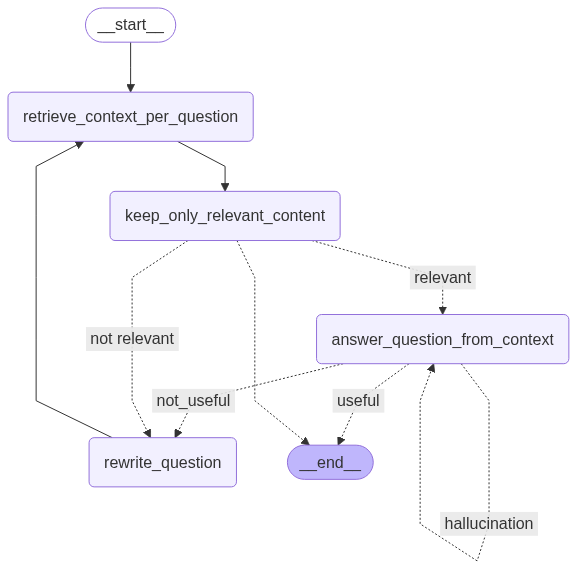

In [250]:
class QualitativeRetievalAnswerGraphState(TypedDict):

    question: str
    context: str
    answer: str

# Create the graph
qualitative_retrieval_answer_workflow = StateGraph(QualitativeRetievalAnswerGraphState)

# Define the nodes

# Add the nodes to the graph
qualitative_retrieval_answer_workflow.add_node("retrieve_context_per_question",retrieve_context_per_question)
qualitative_retrieval_answer_workflow.add_node("keep_only_relevant_content",keep_only_relevant_content)
qualitative_retrieval_answer_workflow.add_node("rewrite_question",rewrite_question)
qualitative_retrieval_answer_workflow.add_node("answer_question_from_context",answer_question_from_context)

# Build the graph
qualitative_retrieval_answer_workflow.set_entry_point("retrieve_context_per_question")
qualitative_retrieval_answer_workflow.add_edge("retrieve_context_per_question", "keep_only_relevant_content")
qualitative_retrieval_answer_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_relevant_content,
    {"relevant":"answer_question_from_context",
      "not relevant":"rewrite_question"},
    )
qualitative_retrieval_answer_workflow.add_edge("rewrite_question", "retrieve_context_per_question")
qualitative_retrieval_answer_workflow.add_conditional_edges(
"answer_question_from_context",
grade_generation_v_documents_and_question,
{"hallucination":"answer_question_from_context",
"not_useful":"rewrite_question",
"useful":END},
)

qualitative_retrieval_answer_retrival_app = qualitative_retrieval_answer_workflow.compile()

display(
    Image(
        qualitative_retrieval_answer_retrival_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

# For more complex tasks, where the question cannot be answered solely by retrieving information based on semantic similarity, we need a more sophisticated pipeline. To achieve this, we may first break down the graph into several sub-graphs that will serve as functions for the sophisticated pipeline.







### Let's add a function that Verifies that the distilled content is grounded in the original context

In [ ]:
is_distilled_content_grounded_on_content_prompt_template = """you receive some distilled content: {distilled_content} and the original context: {original_context}.
    you need to determine if the distilled content is grounded on the original context.
    if the distilled content is grounded on the original context, set the grounded field to true.
    if the distilled content is not grounded on the original context, set the grounded field to false. {format_instructions}"""
  

class IsDistilledContentGroundedOnContent(BaseModel):
    grounded: bool = Field(description="Whether the distilled content is grounded on the original context.")
    explanation: str = Field(description="An explanation of why the distilled content is or is not grounded on the original context.")

is_distilled_content_grounded_on_content_json_parser = JsonOutputParser(pydantic_object=IsDistilledContentGroundedOnContent)

is_distilled_content_grounded_on_content_prompt = PromptTemplate(
    template=is_distilled_content_grounded_on_content_prompt_template,
    input_variables=["distilled_content", "original_context"],
    partial_variables={"format_instructions": is_distilled_content_grounded_on_content_json_parser.get_format_instructions()},
)

is_distilled_content_grounded_on_content_llm = get_planner_model()  # 使用项目统一的planner模型配置

is_distilled_content_grounded_on_content_chain = is_distilled_content_grounded_on_content_prompt | is_distilled_content_grounded_on_content_llm | is_distilled_content_grounded_on_content_json_parser


def is_distilled_content_grounded_on_content(state):
    pprint("--------------------")

    """
    Determines if the distilled content is grounded on the original context.

    Args:
        distilled_content: The distilled content.
        original_context: The original context.

    Returns:
        Whether the distilled content is grounded on the original context.
    """

    print("Determining if the distilled content is grounded on the original context...")
    distilled_content = state["relevant_context"]
    original_context = state["context"]

    input_data = {
        "distilled_content": distilled_content,
        "original_context": original_context
    }

    output = is_distilled_content_grounded_on_content_chain.invoke(input_data)
    grounded = output["grounded"]

    if grounded:
        print("The distilled content is grounded on the original context.")
        return "grounded on the original context"
    else:
        print("The distilled content is not grounded on the original context.")
        return "not grounded on the original context"

### Create functions for each type of retrieval

In [46]:
def retrieve_chunks_context_per_question(state):
    """
    Retrieves relevant context for a given question. The context is retrieved from the book chunks and chapter summaries.

    Args:
        state: A dictionary containing the question to answer.
    """
    # Retrieve relevant documents
    print("Retrieving relevant chunks...")
    question = state["question"]
    docs = chunks_query_retriever.get_relevant_documents(question)

    # Concatenate document content
    context = " ".join(doc.page_content for doc in docs)
    context = escape_quotes(context)
    return {"context": context, "question": question}

def retrieve_summaries_context_per_question(state):

    print("Retrieving relevant chapter summaries...")
    question = state["question"]

    docs_summaries = chapter_summaries_query_retriever.get_relevant_documents(state["question"])

    # Concatenate chapter summaries with citation information
    context_summaries = " ".join(
        f"{doc.page_content} (Chapter {doc.metadata['chapter']})" for doc in docs_summaries
    )
    context_summaries = escape_quotes(context_summaries)
    return {"context": context_summaries, "question": question}

def retrieve_book_quotes_context_per_question(state):
    question = state["question"]

    print("Retrieving relevant book quotes...")
    docs_book_quotes = book_quotes_query_retriever.get_relevant_documents(state["question"])
    book_qoutes = " ".join(doc.page_content for doc in docs_book_quotes)
    book_qoutes_context = escape_quotes(book_qoutes)

    return {"context": book_qoutes_context, "question": question}

## Create sub graph for each type of retrieval

### The first sub-graph would be for retrieval and distillation of the relevant information with some modification

In [54]:
class QualitativeRetrievalGraphState(TypedDict):
    """
    Represents the state of our graph.
    """

    question: str
    context: str
    relevant_context: str

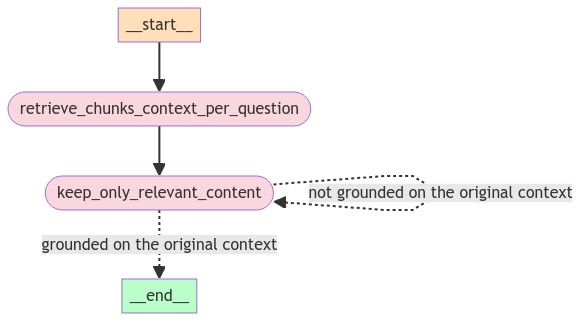

In [61]:
qualitative_chunks_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# Define the nodes
qualitative_chunks_retrieval_workflow.add_node("retrieve_chunks_context_per_question",retrieve_chunks_context_per_question)
qualitative_chunks_retrieval_workflow.add_node("keep_only_relevant_content",keep_only_relevant_content)

# Build the graph
qualitative_chunks_retrieval_workflow.set_entry_point("retrieve_chunks_context_per_question")

qualitative_chunks_retrieval_workflow.add_edge("retrieve_chunks_context_per_question", "keep_only_relevant_content")

qualitative_chunks_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {"grounded on the original context":END,
      "not grounded on the original context":"keep_only_relevant_content"},
    )


qualitative_chunks_retrieval_workflow_app = qualitative_chunks_retrieval_workflow.compile()

display(
    Image(
        qualitative_chunks_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

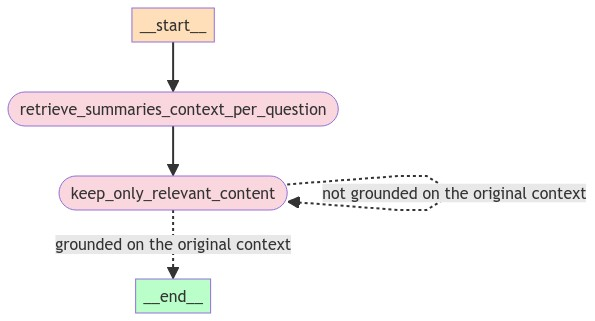

In [62]:
qualitative_summaries_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# Define the nodes
qualitative_summaries_retrieval_workflow.add_node("retrieve_summaries_context_per_question",retrieve_summaries_context_per_question)
qualitative_summaries_retrieval_workflow.add_node("keep_only_relevant_content",keep_only_relevant_content)

# Build the graph
qualitative_summaries_retrieval_workflow.set_entry_point("retrieve_summaries_context_per_question")

qualitative_summaries_retrieval_workflow.add_edge("retrieve_summaries_context_per_question", "keep_only_relevant_content")

qualitative_summaries_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {"grounded on the original context":END,
      "not grounded on the original context":"keep_only_relevant_content"},
    )


qualitative_summaries_retrieval_workflow_app = qualitative_summaries_retrieval_workflow.compile()

display(
    Image(
        qualitative_summaries_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

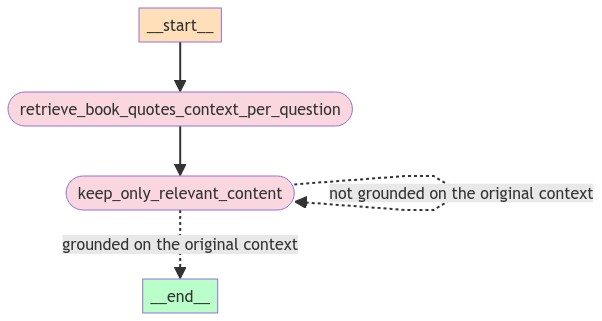

In [63]:
qualitative_book_quotes_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# Define the nodes
qualitative_book_quotes_retrieval_workflow.add_node("retrieve_book_quotes_context_per_question",retrieve_book_quotes_context_per_question)
qualitative_book_quotes_retrieval_workflow.add_node("keep_only_relevant_content",keep_only_relevant_content)

# Build the graph
qualitative_book_quotes_retrieval_workflow.set_entry_point("retrieve_book_quotes_context_per_question")

qualitative_book_quotes_retrieval_workflow.add_edge("retrieve_book_quotes_context_per_question", "keep_only_relevant_content")

qualitative_book_quotes_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {"grounded on the original context":END,
      "not grounded on the original context":"keep_only_relevant_content"},
    )

qualitative_book_quotes_retrieval_workflow_app = qualitative_book_quotes_retrieval_workflow.compile()

display(
    Image(
        qualitative_book_quotes_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

### Test the retreive-and-keep-relevant-content graphs

In [72]:
init_state = {"question": "worse than getting killed"}  # The question to answer

In [ ]:
## test the book chunks retrieval
for output in qualitative_chunks_retrieval_workflow_app.stream(init_state):    
    for _, value in output.items():
        pass 
    pprint("--------------------")
print(f'relevant context: {value["relevant_context"]}')

In [ ]:
## test the chapter summaries retrieval
for output in qualitative_summaries_retrieval_workflow_app.stream(init_state):    
    for _, value in output.items():
        pass 
    pprint("--------------------")
print(f'relevant context: {value["relevant_context"]}')

In [ ]:
## test the book quotes retrieval
for output in qualitative_book_quotes_retrieval_workflow_app.stream(init_state):    
    for _, value in output.items():
        pass 
    pprint("--------------------")
print(f'relevant context: {value["relevant_context"]}')

### Add a shorter version of the answer verification, checking only if grounded on context

In [78]:
def is_answer_grounded_on_context(state):
    """Determines if the answer to the question is grounded in the facts.
    
    Args:
        state: A dictionary containing the context and answer.
    """
    print("Checking if the answer is grounded in the facts...")
    context = state["context"]
    answer = state["answer"]
    
    result = is_grounded_on_facts_chain.invoke({"context": context, "answer": answer})
    grounded_on_facts = result.grounded_on_facts
    if not grounded_on_facts:
        print("The answer is hallucination.")
        return "hallucination"
    else:
        print("The answer is grounded in the facts.")
        return "grounded on context"

### The last sub-graph will be a component that answers a question given context, without hallucinations

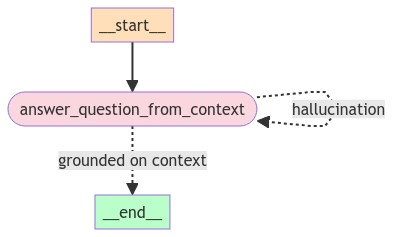

In [79]:
class QualitativeAnswerGraphState(TypedDict):
    """
    Represents the state of our graph.

    """

    question: str
    context: str
    answer: str

qualitative_answer_workflow = StateGraph(QualitativeAnswerGraphState)

# Define the nodes

qualitative_answer_workflow.add_node("answer_question_from_context",answer_question_from_context)

# Build the graph
qualitative_answer_workflow.set_entry_point("answer_question_from_context")

qualitative_answer_workflow.add_conditional_edges(
"answer_question_from_context",is_answer_grounded_on_context ,{"hallucination":"answer_question_from_context", "grounded on context":END}

)

qualitative_answer_workflow_app = qualitative_answer_workflow.compile()

display(
    Image(
        qualitative_answer_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

### Test the answer-from-question-graph

In [81]:
question = "who is harry?" # The question to answer
context = "Harry Potter is a cat." # The context to answer the question from
init_state = {"question": question, "context": context} # The initial state
for output in qualitative_answer_workflow_app.stream(init_state): 
    for _, value in output.items():
        pass  # Node
        # ... (your existing code)
    pprint("--------------------")
print(f'answer: {value["answer"]}')

Answering the question from the retrieved context...
answer before checking hallucination: The context states that Harry Potter is a cat. Therefore, Harry is a cat.
Checking if the answer is grounded in the facts...
The answer is grounded in the facts.
'--------------------'
answer: The context states that Harry Potter is a cat. Therefore, Harry is a cat.


# Now let's define the sophisticated pipeline components

### The state of each step of the graph should be in this structure:

In [82]:
class PlanExecute(TypedDict):
    curr_state: str
    question: str
    anonymized_question: str
    query_to_retrieve_or_answer: str
    plan: List[str]
    past_steps: List[str]
    mapping: dict 
    curr_context: str
    aggregated_context: str
    tool: str
    response: str

### Define the Plan node - constructs a plan composed of steps, of how to tackle a question

In [83]:
class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

planner_prompt =""" For the given query {question}, come up with a simple step by step plan of how to figure out the answer. 

This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. 
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

"""

planner_prompt = PromptTemplate(
    template=planner_prompt,
      input_variables=["question"], 
     )

planner_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)

planner = planner_prompt | planner_llm.with_structured_output(Plan)

### A function to break down each task to either retrieve or answer

In [84]:
break_down_plan_prompt_template = """You receive a plan {plan} which contains a series of steps to follow in order to answer a query. 
you need to go through the plan refine it according to this:
1. every step has to be able to be executed by either:
    i. retrieving relevant information from a vector store of book chunks
    ii. retrieving relevant information from a vector store of chapter summaries
    iii. retrieving relevant information from a vector store of book quotes
    iv. answering a question from a given context.
2. every step should contain all the information needed to execute it.

output the refined plan
"""

break_down_plan_prompt = PromptTemplate(
    template=break_down_plan_prompt_template,
    input_variables=["plan"],
)

break_down_plan_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)

break_down_plan_chain = break_down_plan_prompt | break_down_plan_llm.with_structured_output(Plan)

### Example of how to use the planner


In [85]:
question = {"question": "how did the main character beat the villain?"} # The question to answer
my_plan = planner.invoke(question) # Generate a plan to answer the question
print(my_plan)
refined_plan = break_down_plan_chain.invoke(my_plan.steps) # Refine the plan
print(refined_plan)

steps=['Identify the main character and the villain in the story.', 'Locate the climax or the final confrontation between the main character and the villain.', 'Analyze the actions taken by the main character during this confrontation.', 'Determine the specific action or strategy that led to the defeat of the villain.', 'Summarize the findings to answer how the main character beat the villain.']
steps=['Identify the main character and the villain in the story by retrieving relevant information from a vector store of book chunks, chapter summaries, or book quotes.', 'Locate the climax or the final confrontation between the main character and the villain by retrieving relevant information from a vector store of book chunks, chapter summaries, or book quotes.', 'Analyze the actions taken by the main character during this confrontation by retrieving relevant information from a vector store of book chunks, chapter summaries, or book quotes.', 'Determine the specific action or strategy that 

### Given the original question, the current plan, the past steps, and the so far aggregated information, update the plan

In [86]:
class ActPossibleResults(BaseModel):
    """Possible results of the action."""
    plan: Plan = Field(description="Plan to follow in future.")
    explanation: str = Field(description="Explanation of the action.")
    

act_possible_results_parser = JsonOutputParser(pydantic_object=ActPossibleResults)

replanner_prompt_template =""" For the given objective, come up with a simple step by step plan of how to figure out the answer. 
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. 
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

assume that the answer was not found yet and you need to update the plan accordingly, so the plan should never be empty.

Your objective was this:
{question}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

You already have the following context:
{aggregated_context}

Update your plan accordingly. If further steps are needed, fill out the plan with only those steps.
Do not return previously done steps as part of the plan.

the format is json so escape quotes and new lines.

{format_instructions}

"""

replanner_prompt = PromptTemplate(
    template=replanner_prompt_template,
    input_variables=["question", "plan", "past_steps", "aggregated_context"],
    partial_variables={"format_instructions": act_possible_results_parser.get_format_instructions()},
)

replanner_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)



replanner = replanner_prompt | replanner_llm | act_possible_results_parser

### Define the task handler - decides whether to use the first sub-graph or the second sub-graph to handle each task from the plan

In [103]:
tasks_handler_prompt_template = """You are a task handler that receives a task {curr_task} and have to decide with tool to use to execute the task.
You have the following tools at your disposal:
Tool A: a tool that retrieves relevant information from a vector store of book chunks based on a given query.
- use Tool A when you think the current task should search for information in the book chunks.
Took B: a tool that retrieves relevant information from a vector store of chapter summaries based on a given query.
- use Tool B when you think the current task should search for information in the chapter summaries.
Tool C: a tool that retrieves relevant information from a vector store of quotes from the book based on a given query.
- use Tool C when you think the current task should search for information in the book quotes.
Tool D: a tool that answers a question from a given context.
- use Tool D ONLY when you the current task can be answered by the aggregated context {aggregated_context}

you also receive the last tool used {last_tool}
if {last_tool} was retrieve_chunks, use other tools than Tool A.

You also have the past steps {past_steps} that you can use to make decisions and understand the context of the task.
You also have the initial user's question {question} that you can use to make decisions and understand the context of the task.
if you decide to use Tools A,B or C, output the query to be used for the tool and also output the relevant tool.
if you decide to use Tool D, output the question to be used for the tool, the context, and also that the tool to be used is Tool D.

"""

class TaskHandlerOutput(BaseModel):
    """Output schema for the task handler."""
    query: str = Field(description="The query to be either retrieved from the vector store, or the question that should be answered from context.")
    curr_context: str = Field(description="The context to be based on in order to answer the query.")
    tool: str = Field(description="The tool to be used should be either retrieve_chunks, retrieve_summaries, retrieve_quotes, or answer_from_context.")


task_handler_prompt = PromptTemplate(
    template=tasks_handler_prompt_template,
    input_variables=["curr_task", "aggregated_context", "last_tool" "past_steps", "question"],
)

task_handler_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)
task_handler_chain = task_handler_prompt | task_handler_llm.with_structured_output(TaskHandlerOutput)

### In order to generate a general plan, without any biases based on prior knowledge of any LLM, we anonymize the input question, first, and map the name entities into variables

In [88]:
class AnonymizeQuestion(BaseModel):
    """Anonymized question and mapping."""
    anonymized_question : str = Field(description="Anonymized question.")
    mapping: dict = Field(description="Mapping of original name entities to variables.")
    explanation: str = Field(description="Explanation of the action.")

anonymize_question_parser = JsonOutputParser(pydantic_object=AnonymizeQuestion)


anonymize_question_prompt_template = """ You are a question anonymizer. The input You receive is a string containing several words that
 construct a question {question}. Your goal is to changes all name entities in the input to variables, and remember the mapping of the original name entities to the variables.
 ```example1:
        if the input is \"who is harry potter?\" the output should be \"who is X?\" and the mapping should be {{\"X\": \"harry potter\"}} ```
```example2:
        if the input is \"how did the bad guy played with the alex and rony?\"
          the output should be \"how did the X played with the Y and Z?\" and the mapping should be {{\"X\": \"bad guy\", \"Y\": \"alex\", \"Z\": \"rony\"}}```
 you must replace all name entities in the input with variables, and remember the mapping of the original name entities to the variables.
  output the anonymized question and the mapping in a json format. {format_instructions}"""



anonymize_question_prompt = PromptTemplate(
    template=anonymize_question_prompt_template,
    input_variables=["question"],
    partial_variables={"format_instructions": anonymize_question_parser.get_format_instructions()},
)

anonymize_question_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)
anonymize_question_chain = anonymize_question_prompt | anonymize_question_llm | anonymize_question_parser

### After the plan is constructed based on the anonymized question, we de-anonymize the plan, using the mapped variables

In [89]:
class DeAnonymizePlan(BaseModel):
    """Possible results of the action."""
    plan: List = Field(description="Plan to follow in future. with all the variables replaced with the mapped words.")

de_anonymize_plan_prompt_template = """ you receive a list of tasks: {plan}, where some of the words are replaced with mapped variables. you also receive
the mapping for those variables to words {mapping}. replace all the variables in the list of tasks with the mapped words. if no variables are present,
return the original list of tasks. in any case, just output the updated list of tasks in a json format as described here, without any additional text apart from the
"""


de_anonymize_plan_prompt = PromptTemplate(
    template=de_anonymize_plan_prompt_template,
    input_variables=["plan", "mapping"],
)

de_anonymize_plan_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)
de_anonymize_plan_chain = de_anonymize_plan_prompt | de_anonymize_plan_llm.with_structured_output(DeAnonymizePlan)

### Example of how to build a plan


In [72]:
state1 = {'question': "how did the harry beat quirrell? \n"}  # The question to answer
print(f'question: {state1["question"]}')
anonymized_question_output = anonymize_question_chain.invoke(state1) # Anonymize the question
anonymized_question = anonymized_question_output["anonymized_question"] # Get the anonymized question
mapping = anonymized_question_output["mapping"] # Get the mapping of the original name entities to the variables
print(f'anonimized_querry: {anonymized_question} \n')
print(f'mapping: {mapping} \n')
plan = planner.invoke({"question": anonymized_question}) # Generate a plan to answer the question
print(text_wrap(f'plan: {plan.steps}'))
print("")
deanonimzed_plan = de_anonymize_plan_chain.invoke({"plan": plan.steps, "mapping": mapping}) # De-anonymize the plan
print(text_wrap(f'deanonimized_plan: {deanonimzed_plan.plan}'))

question: how did the harry beat quirrell? 

anonimized_querry: how did the X beat Y? 

mapping: {'X': 'harry', 'Y': 'quirrell'} 

plan: ['Identify the context or domain of the query (e.g., sports, competition, game, etc.).', 'Gather information about
the event or competition where X and Y participated.', 'Find the specific instance or match where X competed against
Y.', 'Look up the results of that specific instance or match.', 'Analyze the details of the match to understand how X
managed to beat Y.', 'Summarize the key points that explain how X beat Y.']

deanonimized_plan: ['Identify the context or domain of the query (e.g., sports, competition, game, etc.).', 'Gather
information about the event or competition where harry and quirrell participated.', 'Find the specific instance or match
where harry competed against quirrell.', 'Look up the results of that specific instance or match.', 'Analyze the details
of the match to understand how harry managed to beat quirrell.', 'Summarize th

### A function that checks if the final answer can be deduced already, based on the aggregated information

In [90]:
class CanBeAnsweredAlready(BaseModel):
    """Possible results of the action."""
    can_be_answered: bool = Field(description="Whether the question can be fully answered or not based on the given context.")

can_be_answered_already_prompt_template = """You receive a query: {question} and a context: {context}.
You need to determine if the question can be fully answered relying only the given context.
The only infomation you have and can rely on is the context you received. 
you have no prior knowledge of the question or the context.
if you think the question can be answered based on the context, output 'true', otherwise output 'false'.
"""

can_be_answered_already_prompt = PromptTemplate(
    template=can_be_answered_already_prompt_template,
    input_variables=["question","context"],
)

can_be_answered_already_llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=2000)
can_be_answered_already_chain = can_be_answered_already_prompt | can_be_answered_already_llm.with_structured_output(CanBeAnsweredAlready)

### Define the sophisticated pipeline graph functions

In [104]:
def run_task_handler_chain(state: PlanExecute):
    """ Run the task handler chain to decide which tool to use to execute the task.
    Args:
       state: The current state of the plan execution.
    Returns:
       The updated state of the plan execution.
    """
    state["curr_state"] = "task_handler"
    print("the current plan is:")
    print(state["plan"])
    pprint("--------------------") 

    if not state['past_steps']:
        state["past_steps"] = []

    curr_task = state["plan"][0]

    inputs = {"curr_task": curr_task,
               "aggregated_context": state["aggregated_context"],
                "last_tool": state["tool"],
                "past_steps": state["past_steps"],
                "question": state["question"]}
    
    output = task_handler_chain.invoke(inputs)
  
    state["past_steps"].append(curr_task)
    state["plan"].pop(0)

    if output.tool == "retrieve_chunks":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"]="retrieve_chunks"
    
    elif output.tool == "retrieve_summaries":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"]="retrieve_summaries"

    elif output.tool == "retrieve_quotes":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"]="retrieve_quotes"

    
    elif output.tool == "answer_from_context":
        state["query_to_retrieve_or_answer"] = output.query
        state["curr_context"] = output.curr_context
        state["tool"]="answer"
    else:
        raise ValueError("Invalid tool was outputed. Must be either 'retrieve' or 'answer_from_context'")
    return state  



def retrieve_or_answer(state: PlanExecute):
    """Decide whether to retrieve or answer the question based on the current state.
    Args:
        state: The current state of the plan execution.
    Returns:
        updates the tool to use .
    """
    state["curr_state"] = "decide_tool"
    print("deciding whether to retrieve or answer")
    if state["tool"] == "retrieve_chunks":
        return "chosen_tool_is_retrieve_chunks"
    elif state["tool"] == "retrieve_summaries":
        return "chosen_tool_is_retrieve_summaries"
    elif state["tool"] == "retrieve_quotes":
        return "chosen_tool_is_retrieve_quotes"
    elif state["tool"] == "answer":
        return "chosen_tool_is_answer"
    else:
        raise ValueError("Invalid tool was outputed. Must be either 'retrieve' or 'answer_from_context'")  

def run_qualitative_chunks_retrieval_workflow(state):
    """
    Run the qualitative chunks retrieval workflow.
    Args:
        state: The current state of the plan execution.
    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "retrieve_chunks"
    print("Running the qualitative chunks retrieval workflow...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_chunks_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    state["aggregated_context"] += output['relevant_context']
    return state

def run_qualitative_summaries_retrieval_workflow(state):
    """
    Run the qualitative summaries retrieval workflow.
    Args:
        state: The current state of the plan execution.
    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "retrieve_summaries"
    print("Running the qualitative summaries retrieval workflow...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_summaries_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    state["aggregated_context"] += output['relevant_context']
    return state

def run_qualitative_book_quotes_retrieval_workflow(state):
    """
    Run the qualitative book quotes retrieval workflow.
    Args:
        state: The current state of the plan execution.
    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "retrieve_book_quotes"
    print("Running the qualitative book quotes retrieval workflow...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_book_quotes_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    state["aggregated_context"] += output['relevant_context']
    return state
   


def run_qualtative_answer_workflow(state):
    """
    Run the qualitative answer workflow.
    Args:
        state: The current state of the plan execution.
    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "answer"
    print("Running the qualitative answer workflow...")
    question = state["query_to_retrieve_or_answer"]
    context = state["curr_context"]
    inputs = {"question": question, "context": context}
    for output in qualitative_answer_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    state["aggregated_context"] += output["answer"]
    return state

def run_qualtative_answer_workflow_for_final_answer(state):
    """
    Run the qualitative answer workflow for the final answer.
    Args:
        state: The current state of the plan execution.
    Returns:
        The state with the updated response.
    """
    state["curr_state"] = "get_final_answer"
    print("Running the qualitative answer workflow for final answer...")
    question = state["question"]
    context = state["aggregated_context"]
    inputs = {"question": question, "context": context}
    for output in qualitative_answer_workflow_app.stream(inputs):
        for _, value in output.items():
            pass  
        pprint("--------------------")
    state["response"] = value
    return state


def anonymize_queries(state: PlanExecute):
    """
    Anonymizes the question.
    Args:
        state: The current state of the plan execution.
    Returns:
        The updated state with the anonymized question and mapping.
    """
    state["curr_state"] = "anonymize_question"
    print("Anonymizing question")
    pprint("--------------------")
    anonymized_question_output = anonymize_question_chain.invoke(state['question'])
    anonymized_question = anonymized_question_output["anonymized_question"]
    print(f'anonimized_querry: {anonymized_question}')
    pprint("--------------------")
    mapping = anonymized_question_output["mapping"]
    state["anonymized_question"] = anonymized_question
    state["mapping"] = mapping
    return state


def deanonymize_queries(state: PlanExecute):
    """
    De-anonymizes the plan.
    Args:
        state: The current state of the plan execution.
    Returns:
        The updated state with the de-anonymized plan.
    """
    state["curr_state"] = "de_anonymize_plan"
    print("De-anonymizing plan")
    pprint("--------------------")
    deanonimzed_plan = de_anonymize_plan_chain.invoke({"plan": state["plan"], "mapping": state["mapping"]})
    state["plan"] = deanonimzed_plan.plan
    print(f'de-anonimized_plan: {deanonimzed_plan.plan}')
    return state


def plan_step(state: PlanExecute):
    """
    Plans the next step.
    Args:
        state: The current state of the plan execution.
    Returns:
        The updated state with the plan.
    """
    state["curr_state"] = "planner"
    print("Planning step")
    pprint("--------------------")
    plan = planner.invoke({"question": state['anonymized_question']})
    state["plan"] = plan.steps
    print(f'plan: {state["plan"]}')
    return state


def break_down_plan_step(state: PlanExecute):
    """
    Breaks down the plan steps into retrievable or answerable tasks.
    Args:
        state: The current state of the plan execution.
    Returns:
        The updated state with the refined plan.
    """
    state["curr_state"] = "break_down_plan"
    print("Breaking down plan steps into retrievable or answerable tasks")
    pprint("--------------------")
    refined_plan = break_down_plan_chain.invoke(state["plan"])
    state["plan"] = refined_plan.steps
    return state



def replan_step(state: PlanExecute):
    """
    Replans the next step.
    Args:
        state: The current state of the plan execution.
    Returns:
        The updated state with the plan.
    """
    state["curr_state"] = "replan"
    print("Replanning step")
    pprint("--------------------")
    inputs = {"question": state["question"], "plan": state["plan"], "past_steps": state["past_steps"], "aggregated_context": state["aggregated_context"]}
    output = replanner.invoke(inputs)
    state["plan"] = output['plan']['steps']
    return state


def can_be_answered(state: PlanExecute):
    """
    Determines if the question can be answered.
    Args:
        state: The current state of the plan execution.
    Returns:
        whether the original question can be answered or not.
    """
    state["curr_state"] = "can_be_answered_already"
    print("Checking if the ORIGINAL QUESTION can be answered already")
    pprint("--------------------")
    question = state["question"]
    context = state["aggregated_context"]
    inputs = {"question": question, "context": context}
    output = can_be_answered_already_chain.invoke(inputs)
    if output.can_be_answered == True:
        print("The ORIGINAL QUESTION can be fully answered already.")
        pprint("--------------------")
        print("the aggregated context is:")
        print(text_wrap(state["aggregated_context"]))
        print("--------------------")
        return "can_be_answered_already"
    else:
        print("The ORIGINAL QUESTION cannot be fully answered yet.")
        pprint("--------------------")
        return "cannot_be_answered_yet"

### Define the sophisticated graph structure

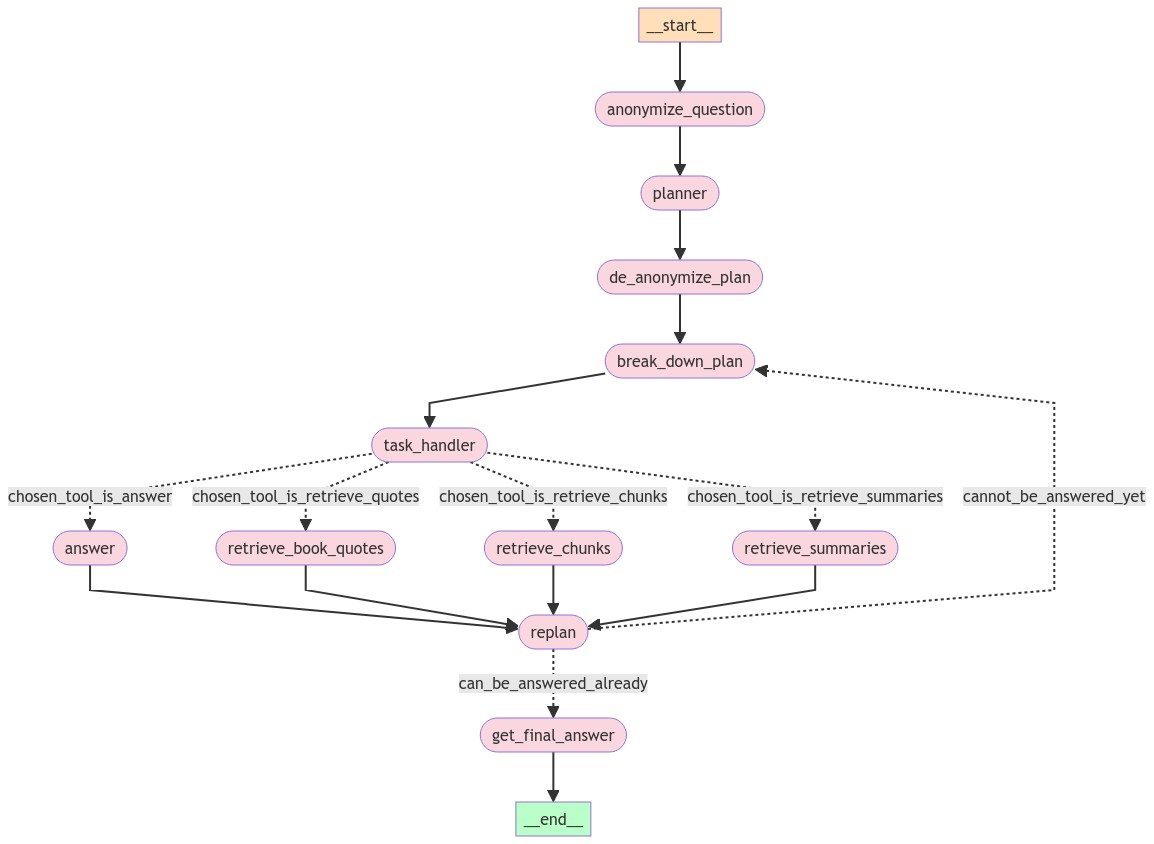

In [100]:
from langgraph.graph import StateGraph

agent_workflow = StateGraph(PlanExecute)

# Add the anonymize node
agent_workflow.add_node("anonymize_question", anonymize_queries)

# Add the plan node
agent_workflow.add_node("planner", plan_step)

# Add the break down plan node

agent_workflow.add_node("break_down_plan", break_down_plan_step)

# Add the deanonymize node
agent_workflow.add_node("de_anonymize_plan", deanonymize_queries)

# Add the qualitative chunks retrieval node
agent_workflow.add_node("retrieve_chunks", run_qualitative_chunks_retrieval_workflow)

# Add the qualitative summaries retrieval node
agent_workflow.add_node("retrieve_summaries", run_qualitative_summaries_retrieval_workflow)

# Add the qualitative book quotes retrieval node
agent_workflow.add_node("retrieve_book_quotes", run_qualitative_book_quotes_retrieval_workflow)


# Add the qualitative answer node
agent_workflow.add_node("answer", run_qualtative_answer_workflow)

# Add the task handler node
agent_workflow.add_node("task_handler", run_task_handler_chain)

# Add a replan node
agent_workflow.add_node("replan", replan_step)

# Add answer from context node
agent_workflow.add_node("get_final_answer", run_qualtative_answer_workflow_for_final_answer)

# Set the entry point
agent_workflow.set_entry_point("anonymize_question")

# From anonymize we go to plan
agent_workflow.add_edge("anonymize_question", "planner")

# From plan we go to deanonymize
agent_workflow.add_edge("planner", "de_anonymize_plan")

# From deanonymize we go to break down plan

agent_workflow.add_edge("de_anonymize_plan", "break_down_plan")

# From break_down_plan we go to task handler
agent_workflow.add_edge("break_down_plan", "task_handler")

# From task handler we go to either retrieve or answer
agent_workflow.add_conditional_edges("task_handler", retrieve_or_answer, {"chosen_tool_is_retrieve_chunks": "retrieve_chunks", "chosen_tool_is_retrieve_summaries":
                                                                           "retrieve_summaries", "chosen_tool_is_retrieve_quotes": "retrieve_book_quotes", "chosen_tool_is_answer": "answer"})

# After retrieving we go to replan
agent_workflow.add_edge("retrieve_chunks", "replan")

agent_workflow.add_edge("retrieve_summaries", "replan")

agent_workflow.add_edge("retrieve_book_quotes", "replan")

# After answering we go to replan
agent_workflow.add_edge("answer", "replan")

# After replanning we check if the question can be answered, if yes we go to get_final_answer, if not we go to task_handler
agent_workflow.add_conditional_edges("replan",can_be_answered, {"can_be_answered_already": "get_final_answer", "cannot_be_answered_yet": "break_down_plan"})

# After getting the final answer we end
agent_workflow.add_edge("get_final_answer", END)


plan_and_execute_app = agent_workflow.compile()

display(Image(plan_and_execute_app.get_graph(xray=True).draw_mermaid_png()))

### Run the sophisticated graph function

In [105]:
def execute_plan_and_print_steps(inputs, recursion_limit=45):
    """
    Execute the plan and print the steps.
    Args:
        inputs: The inputs to the plan.
        recursion_limit: The recursion limit.
    Returns:
        The response and the final state.
    """
    
    config = {"recursion_limit": recursion_limit}
    try:    
        for plan_output in plan_and_execute_app.stream(inputs, config=config):
            for _, agent_state_value in plan_output.items():
                pass
                print(f' curr step: {agent_state_value}')
        response = agent_state_value['response']
    except langgraph.pregel.GraphRecursionError:
        response = "The answer wasn't found in the data."
    final_state = agent_state_value
    print(text_wrap(f' the final answer is: {response}'))
    return response, final_state

### Examples

#### An example we want the model to fail

In [ ]:
input = {"question": "what did professor lupin teach?"}
final_answer, final_state = execute_plan_and_print_steps(input)

#### An example we want the model to succeed

In [ ]:
input = {"question": "what is the class that the proffessor who helped the villain is teaching?"}
final_answer, final_state = execute_plan_and_print_steps(input)

#### An example that demonstrates the CoT reasoning, when answering a question

In [ ]:
input = {"question": "how did harry beat quirrell?"}
final_answer, final_state = execute_plan_and_print_steps(input)

### Model Evaluation


In [102]:
questions = [
    "What is the name of the three-headed dog guarding the Sorcerer's Stone?",
    "Who gave Harry Potter his first broomstick?",
    "Which house did the Sorting Hat initially consider for Harry?",
    # "What is the name of Harry's owl?"
]
#     "How did Harry and his friends get past Fluffy?",
#     "What is the Mirror of Erised?",
#     "Who tried to steal the Sorcerer's Stone?",
#     "How did Harry defeat Quirrell?",
#     "What is Harry's parent's secret weapon against Voldemort?",
# ]

ground_truth_answers = [
    "Fluffy",
    "Professor McGonagall",
    "Slytherin",
    # "Hedwig",
    # "They played music to put Fluffy to sleep.",
    # "A magical mirror that shows the 'deepest, most desperate desire of our hearts.'",
    # "Professor Quirrell, possessed by Voldemort",
    # "Harry's mother's love protected him, causing Quirrell/Voldemort pain when they touched him.",
]

### Generating Answers and Retrieving Documents for Predefined Questions


In [ ]:
generated_answers = [] # To store the generated answers
retrieved_documents = [] # To store the retrieved documents
for question in questions:
    input = {"question": question} # The input to the plan
    print(f"Answering the question: {question}")
    final_answer, final_state = execute_plan_and_print_steps(input) # Execute the pipeline 
    generated_answers.append(final_answer) # Append the generated answer
    retrieved_documents.append(final_state['aggregated_context']) # Append the retrieved documents

### Displaying Retrieved Documents and Generated Answers


In [ ]:
print(text_wrap(f'retrieved_documents: {retrieved_documents}\n'))
print(text_wrap(f'generated_answers: {generated_answers}'))

### Preparing Data and Conducting Ragas Evaluation


In [123]:
# Prepare data for Ragas evaluation
data_samples = {
    'question': questions,  # Replace with your list of questions
    'answer': generated_answers,  # Replace with your list of generated answers
    'contexts': retrieved_documents,  # Your retrieved_documents list
    'ground_truth': ground_truth_answers  # Replace with your list of ground truth answers
}

# Convert contexts to list of strings (if necessary)
data_samples['contexts'] = [list(context) for context in data_samples['contexts']]

dataset = Dataset.from_dict(data_samples)

# Evaluate using Ragas with the specified metrics
metrics = [
    answer_correctness,
    faithfulness,
    answer_relevancy,
    context_recall,
    answer_similarity
]
llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=4000)
score = evaluate(dataset, metrics=metrics, llm=llm)

# Print results and explanations
results_df = score.to_pandas()
print(results_df)

Evaluating: 100%|██████████| 15/15 [00:51<00:00,  3.44s/it]


                                            question                answer  \
0  What is the name of the three-headed dog guard...                Fluffy   
1        Who gave Harry Potter his first broomstick?  Professor McGonagall   
2  Which house did the Sorting Hat initially cons...             Slytherin   

                                            contexts          ground_truth  \
0  [I, n,  , C, h, a, p, t, e, r,  , S, i, x, t, ...                Fluffy   
1  [I, n,  , C, h, a, p, t, e, r,  , E, i, g, h, ...  Professor McGonagall   
2  [T, h, e,  , S, o, r, t, i, n, g,  , H, a, t, ...             Slytherin   

   answer_correctness  faithfulness  answer_relevancy  context_recall  \
0                 1.0           1.0          1.000000             1.0   
1                 1.0           1.0          0.946824             1.0   
2                 1.0           0.0          0.889830             0.0   

   answer_similarity  
0                1.0  
1                1.0  
2           

### Analyzing Metric Results from Ragas Evaluation


## 🔍 RAG 管道调试执行

以下代码将原来的一行代码拆分为多个步骤，每步都有详细的输出以便调试：

1. **步骤1**: 初始化状态 - 设置要回答的问题
2. **步骤2**: 检索上下文 - 从向量存储中检索相关文档
3. **步骤3**: 保留相关内容 - 筛选出与问题相关的内容
4. **步骤4**: 检查内容相关性 - 验证内容是否真的相关
5. **步骤5**: 基于上下文回答问题 - 生成答案
6. **步骤6**: 评分和最终答案 - 对答案进行评估

每个步骤都会输出详细的调试信息，帮助您了解数据在管道中的流转过程。

In [30]:
# 步骤1: 初始化状态
init_state = {"question": "1日元是多少人民币?"}  # The question to answer

print("=" * 60)
print("步骤1: 初始化状态")
print("=" * 60)
print(f"初始问题: {init_state['question']}")
print(f"初始状态: {init_state}")
print()

步骤1: 初始化状态
初始问题: 1日元是多少人民币?
初始状态: {'question': '1日元是多少人民币?'}



In [31]:
# 步骤2: 检索上下文
context_state = retrieve_context_per_question(init_state)  # Retrieve context for the question

print("=" * 60)
print("步骤2: 检索上下文")
print("=" * 60)

# 打印返回的状态中包含的键，以确认实际的数据结构
print(f"上下文状态键: {list(context_state.keys())}")

# 从返回的 state 中获取合并后的上下文内容
# 函数返回的是一个名为 'context' 的键，其值是所有文档内容的字符串拼接
retrieved_context_string = context_state.get('context', '')

# 检查是否检索到了内容，并打印其长度和预览
if retrieved_context_string:
    print(f"\n检索到的合并后上下文总长度: {len(retrieved_context_string)} 个字符")
    print("\n合并后上下文内容预览:")
    # 显示前500个字符作为预览，因为内容可能非常长
    print(f"  内容: {retrieved_context_string[:500]}...")
else:
    # 如果 context 字符串为空，说明三个向量数据库都没有返回任何内容
    print("\n未能检索到任何相关的上下文内容。")

print()

Retrieving relevant chunks...
Retrieving relevant chapter summaries...
Retrieving relevant book quotes...
步骤2: 检索上下文
上下文状态键: ['context', 'question']

检索到的合并后上下文总长度: 2470 个字符

合并后上下文内容预览:
  内容: 中国与日本生育及教育支持政策对比分析报告 
1. 引言 
本报告旨在深入剖析中国近期在生育和教育领域出台的系列支持政策，特别是针对新生儿的育儿 
补贴、幼儿园至高中阶段的学费减免以及每月生活补贴等措施的真实性与具体细节。同时，报告 
将对日本在应对人口结构变化方面所采取的类似政策进行横向比较，并统一将所有补贴金额换算 
为人民币（按 1 日元 =0.05 人民币的汇率），以提供清晰直观的参考，帮助理解两国在减轻家庭育 
儿负担、鼓励生育方面的策略与实践。 
近年来，中国和日本两国均面临着严峻的人口结构挑战，包括生育率持续下降和人口老龄化加 
剧。这些趋势对社会经济发展构成了长期性影响，促使两国政府积极出台并完善一系列旨在减轻 
家庭育儿成本、提升生育意愿的政策措施。本报告将详细阐述这些政策的具体内容、实施范围及 
其可能带来的社会经济影响。 
用户对这些政策的关注，特别是对生育补贴、免费教育和生活补贴的询问，恰好触及了当前中日 
两国应对人口挑战的核心政策方向。两国政府通过经济激励和教育减负等手段进行干预，表明两 
国都深刻认识到人口结构对社会经济长期可持续发展的重要性。观察政策的演变...



In [32]:
# 步骤3: 保留相关内容
relevant_content_state = keep_only_relevant_content(context_state)  # Keep only the relevant content

print("=" * 60)
print("步骤3: 保留相关内容")
print("=" * 60)
print(f"处理后的状态键: {list(relevant_content_state.keys())}")

if 'relevant_content' in relevant_content_state:
    relevant_content = relevant_content_state['relevant_content']
    print(f"相关内容长度: {len(relevant_content)} 字符")
    print(f"相关内容预览: {relevant_content[:200]}...")
else:
    print("没有找到 'relevant_content' 键")

print(f"完整状态: {relevant_content_state}")
print()

keeping only the relevant content...
Input data: query='1日元是多少人民币?...', context length=2470
LLM output type: <class 'NoneType'>
LLM output: None
❌ LLM returned None, using fallback
步骤3: 保留相关内容
处理后的状态键: ['relevant_context', 'context', 'question']
没有找到 'relevant_content' 键
完整状态: {'relevant_context': '中国与日本生育及教育支持政策对比分析报告 \n1. 引言 \n本报告旨在深入剖析中国近期在生育和教育领域出台的系列支持政策，特别是针对新生儿的育儿 \n补贴、幼儿园至高中阶段的学费减免以及每月生活补贴等措施的真实性与具体细节。同时，报告 \n将对日本在应对人口结构变化方面所采取的类似政策进行横向比较，并统一将所有补贴金额换算 \n为人民币（按 1 日元 =0.05 人民币的汇率），以提供清晰直观的参考，帮助理解两国在减轻家庭育 \n儿负担、鼓励生育方面的策略与实践。 \n近年来，中国和日本两国均面临着严峻的人口结构挑战，包括生育率持续下降和人口老龄化加 \n剧。这些趋势对社会经济发展构成了长期性影响，促使两国政府积极出台并完善一系列旨在减轻 \n家庭育儿成本、提升生育意愿的政策措施。本报告将详细阐述这些政策的具体内容、实施范围及 \n其可能带来的社会经济影响。 \n用户对这些政策的关注，特别是对生育补贴、免费教育和生活补贴的询问，恰好触及了当前中日 \n两国应对人口挑战的核心政策方向。两国政府通过经济激励和教育减负等手段进行干预，表明两 \n国都深刻认识到人口结构对社会经济长期可持续发展的重要性。观察政策的演变，可以发现中国 \n在应对人口问题上的策略已从最初的 “ 松绑生育 ” （如全面二孩、三孩政策）逐步转向更为积极的 \n“ 促进生育 ” 阶段  1 。这种转变不仅是简单地放开生育限制，更是通过提供实质性的经济和社会支 \n持，旨在降低家庭的生育养育成本，从而激发和提升生育意愿。这一策略的深化反映了对人口学 \n规律和家庭决策机制更深层次的理解。 \n2. 中国生育与教育

In [ ]:
# 步骤4: 检查内容相关性
is_relevant_content_state = is_relevant_content(relevant_content_state)  # Check if the content is relevant

print("=" * 60)
print("步骤4: 检查内容相关性")
print("=" * 60)
print(f"相关性检查结果类型: {type(is_relevant_content_state)}")
print(f"相关性检查结果: {is_relevant_content_state}")

if isinstance(is_relevant_content_state, dict):
    if 'is_relevant' in is_relevant_content_state:
        print(f"内容是否相关: {is_relevant_content_state['is_relevant']}")
    if 'explanation' in is_relevant_content_state:
        print(f"解释: {is_relevant_content_state['explanation']}")
elif hasattr(is_relevant_content_state, 'is_relevant'):
    print(f"内容是否相关: {is_relevant_content_state.is_relevant}")
    print(f"解释: {is_relevant_content_state.explanation}")
print()

In [ ]:
# 步骤5: 基于上下文回答问题
answer_state = answer_question_from_context(relevant_content_state)  # Answer the question from the context

print("=" * 60)
print("步骤5: 基于上下文回答问题")
print("=" * 60)
print(f"回答状态键: {list(answer_state.keys())}")

if 'answer' in answer_state:
    answer = answer_state['answer']
    print(f"生成的答案: {answer}")
    print(f"答案长度: {len(answer)} 字符")
else:
    print("没有找到 'answer' 键")

if 'question' in answer_state:
    print(f"原始问题: {answer_state['question']}")

print(f"完整答案状态: {answer_state}")
print()

In [ ]:
# 步骤6: 评分和最终答案
final_answer = grade_generation_v_documents_and_question(answer_state)  # Grade the answer

print("=" * 60)
print("步骤6: 评分和最终答案")
print("=" * 60)
print(f"最终答案状态类型: {type(final_answer)}")
print(f"最终答案状态: {final_answer}")

if isinstance(final_answer, dict):
    if 'answer' in final_answer:
        print(f"最终答案: {final_answer['answer']}")
    if 'grade' in final_answer:
        print(f"评分: {final_answer['grade']}")
    for key, value in final_answer.items():
        if key not in ['answer', 'grade']:
            print(f"{key}: {value}")

print("\n" + "=" * 60)
print("最终结果")
print("=" * 60)
print(f"最终答案: {answer_state['answer']}")
print("=" * 60)